In [2]:
import os
import glob
import json
import yaml
import numpy as np
import torch
import argparse
import igl
import pickle
import trimesh

import sys
from pathlib import Path
__abs_path__ = str(Path.cwd().parents[0].absolute())
__utils_path__ = f'{__abs_path__}/utils'

for __util_path__ in [__abs_path__, __utils_path__]:
    if not __util_path__ in sys.path:
        sys.path+=[__util_path__]

try:
    from matplotrender import *
except:
    !pip install git+https://github.com/chacorp/matplotrender.git
    from matplotrender import *

from utils.matplotlib_rnd import (
    render_mesh_diff,
    plot_image_array,
    plot_image_array_grd,
    plot_image_array_diff2,
)

from dataloader_CBD import (
    EvalDataset,
    CBDDataBatch_eval,
    CBD_collate_wrapper_eval,
)
from functools import partial
from tqdm import tqdm
from glob import glob
import igl

import ipywidgets as widgets
import matplotlib.pyplot as plt

In [3]:
# import pygeodesic
# import pygeodesic.geodesic as geodesic

from utils.remesh_utils import ICT_face_model

ict_face_model = ICT_face_model()
ict_tri = ict_face_model.get_mesh()
# geoalg = geodesic.PyGeodesicAlgorithmExact(ict_tri.vertices, ict_tri.faces)

## about geodesic

In [3]:
# from tqdm import tqdm

# GD_matrix = np.zeros((len(ict_tri.vertices), len(ict_tri.vertices)))

# for sourceIndex in tqdm(range(len(ict_tri.vertices))):
#     source_indices = np.array([sourceIndex])
#     distances, best_source = geoalg.geodesicDistances(source_indices)
#     GD_matrix[sourceIndex] = distances
#     # if sourceIndex % 10==0:
#     #     print(sourceIndex)
#     # print(distances, best_source)
#     # print(distances.shape, best_source.shape)
#     # break

In [5]:
from torch_geometric.utils import geodesic_distance
import torch

# pos: [num_nodes, 3], face: [3, num_faces]
pos = torch.tensor([[0.0, 0.0, 0.0], [2.0, 0.0, 0.0], [0.0, 2.0, 0.0], [2.0, 2.0, 0.0]])
face = torch.tensor([[0, 1, 2], [1, 2, 3]], dtype=torch.long) # Example face indices


pos = torch.from_numpy(ict_tri.vertices)
face = torch.from_numpy(ict_tri.faces.transpose(1,0))

NV = ict_tri.vertices.shape[0]
# for i in tqdm(range(1)):
gdistances_all = torch.zeros((NV, NV))

for i in tqdm(range(len(ict_tri.vertices))):
    gdistances_all[i] = geodesic_distance(
        pos, face, 
        torch.tensor([i]),
        # torch.tensor([i,i+1]),
        # torch.arange(128),
        norm=False,
        max_distance=0.5,
        # num_workers=12
    )

NameError: name 'ict_tri' is not defined

In [51]:
distances = gdistances_all
print(distances)
distances_max = distances.max()
print(distances.shape, distances_max)

distances[distances>=distances_max]=0.5
distances_max = distances.max()
print(distances_max)
distances = distances / distances_max
print(distances)
distances = 1 - distances

tensor([[0.0000, 0.0419, 0.0154,  ..., 0.5000, 0.5000, 0.5000],
        [0.0419, 0.0000, 0.0265,  ..., 0.5000, 0.5000, 0.5000],
        [0.0154, 0.0265, 0.0000,  ..., 0.5000, 0.5000, 0.5000],
        ...,
        [0.5000, 0.5000, 0.5000,  ..., 0.0000, 0.1705, 0.3414],
        [0.5000, 0.5000, 0.5000,  ..., 0.1705, 0.0000, 0.1711],
        [0.5000, 0.5000, 0.5000,  ..., 0.3414, 0.1711, 0.0000]])
torch.Size([11248, 11248]) tensor(0.5088)
tensor(0.5087)
tensor([[0.0000, 0.0824, 0.0303,  ..., 0.9830, 0.9830, 0.9830],
        [0.0824, 0.0000, 0.0521,  ..., 0.9830, 0.9830, 0.9830],
        [0.0303, 0.0521, 0.0000,  ..., 0.9830, 0.9830, 0.9830],
        ...,
        [0.9830, 0.9830, 0.9830,  ..., 0.0000, 0.3352, 0.6711],
        [0.9830, 0.9830, 0.9830,  ..., 0.3352, 0.0000, 0.3365],
        [0.9830, 0.9830, 0.9830,  ..., 0.6711, 0.3365, 0.0000]])


In [7]:
def cal_geodesic_distance_for_all(vertices, faces, max_distance=0.5):
    pos = vertices
    face = faces.transpose(1,0)
    
    NV = vertices.shape[0]
    
    gdistances_all = torch.zeros((NV, NV))
    
    for i in tqdm(range(len(vertices))):
        gdistances_all[i] = geodesic_distance(
            pos, face, 
            torch.tensor([i]),
            norm=False,
            max_distance=max_distance,
        )
    return gdistances_all

In [8]:
# mf_data_split['train'] + mf_data_split['val'] + mf_data_split['test']


mf ROM data list exists: /source/sihun/NeuralFacialAnimation/utils/data/mf_ROM_vertex_data_test.txt
13


100%|██████████| 5223/5223 [02:54<00:00, 29.96it/s]


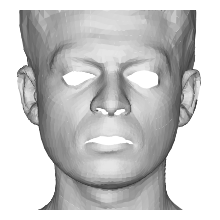

100%|██████████| 5223/5223 [02:33<00:00, 34.08it/s]


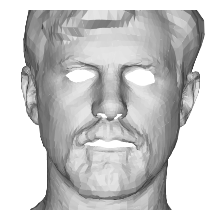

100%|██████████| 5223/5223 [02:42<00:00, 32.18it/s]


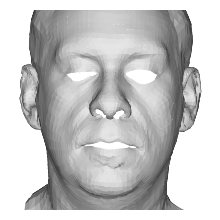

100%|██████████| 5223/5223 [02:35<00:00, 33.60it/s]


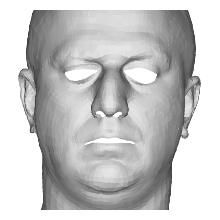

100%|██████████| 5223/5223 [02:39<00:00, 32.77it/s]


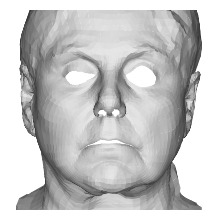

100%|██████████| 5223/5223 [02:37<00:00, 33.26it/s]


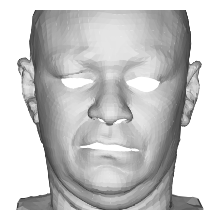

100%|██████████| 5223/5223 [02:42<00:00, 32.12it/s]


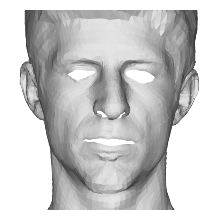

100%|██████████| 5223/5223 [02:46<00:00, 31.44it/s]


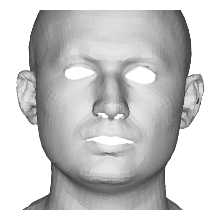

100%|██████████| 5223/5223 [02:48<00:00, 30.95it/s]


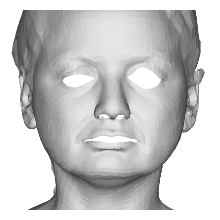

100%|██████████| 5223/5223 [02:50<00:00, 30.60it/s]


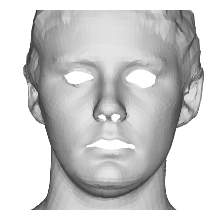

100%|██████████| 5223/5223 [02:47<00:00, 31.16it/s]


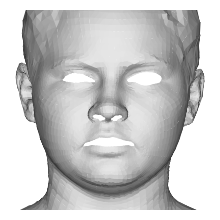

100%|██████████| 5223/5223 [02:51<00:00, 30.38it/s]


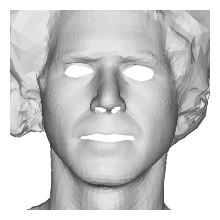

100%|██████████| 5223/5223 [02:51<00:00, 30.48it/s]


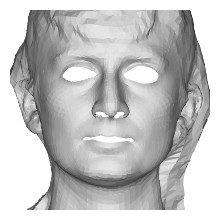

In [12]:
import pickle
from utils.keys import mf_data_split

# mode = 'train'

data_name_list = ['voca','biwi','mf_SEN','coma','mf_ROM','ict','ict-cap'] # 0 1 2 3 4 5 6

SRC_SELECT_DATA=4
src_selection = data_name_list[SRC_SELECT_DATA]
src_dataset = EvalDataset(data_name=src_selection, toggle=False) # if eve-s01

data_ids = mf_data_split['train'] + mf_data_split['val'] + mf_data_split['test']
num_ids = len(data_ids)
print(num_ids)

save_path ='/data/sihun/pca/multiface_align'
gd_save_path = os.path.join(save_path, 'geodesics')
os.makedirs(gd_save_path, exist_ok=True)

for n_id in range(num_ids):
    SRC_SELECT_MESH=n_id
    id_name = data_ids[n_id]
    id_save_file_path = os.path.join(gd_save_path, id_name+'.pkl')
    
    if os.path.exists(id_save_file_path):
        continue    
    src_v, src_f = get_mesh(src_selection, src_dataset, SRC_SELECT_MESH)
    
    src_v_th = torch.from_numpy(src_v)
    src_f_th = torch.from_numpy(src_f)

    geodistances_all = cal_geodesic_distance_for_all(
        src_v_th, src_f_th, max_distance=1.0
    )
    
    v_list=[src_v]
    f_list=[src_f]
    plot_image_array(
        v_list, f_list,
        rot_list=[[0,0,0]]*len(v_list),
        size=2, bg_black=False, mode='shade', save=False
    )

    id_save_file_path = os.path.join(gd_save_path, id_name+'.pkl')
    with open(id_save_file_path, 'wb') as f:
        pickle.dump(geodistances_all, f)
    # break

111


100%|██████████| 11248/11248 [09:08<00:00, 20.50it/s]


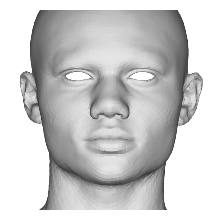

100%|██████████| 11248/11248 [08:57<00:00, 20.93it/s]


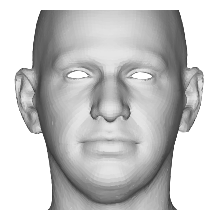

100%|██████████| 11248/11248 [09:14<00:00, 20.30it/s]


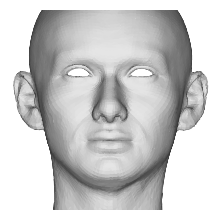

100%|██████████| 11248/11248 [08:46<00:00, 21.37it/s]


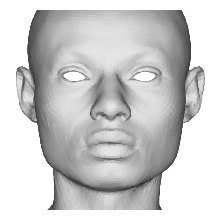

100%|██████████| 11248/11248 [08:45<00:00, 21.39it/s]


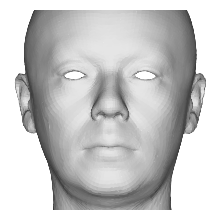

100%|██████████| 11248/11248 [09:15<00:00, 20.25it/s]


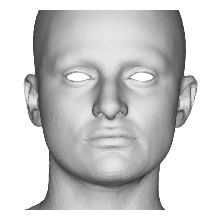

100%|██████████| 11248/11248 [09:37<00:00, 19.49it/s]


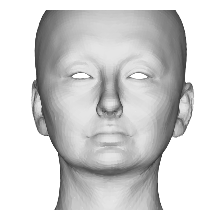

100%|██████████| 11248/11248 [08:47<00:00, 21.31it/s]


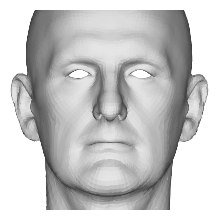

100%|██████████| 11248/11248 [08:41<00:00, 21.57it/s]


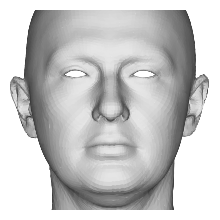

100%|██████████| 11248/11248 [08:26<00:00, 22.22it/s]


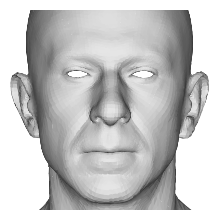

100%|██████████| 11248/11248 [08:50<00:00, 21.20it/s]


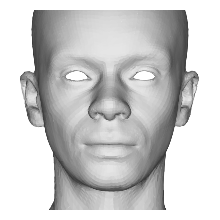

100%|██████████| 11248/11248 [08:56<00:00, 20.98it/s]


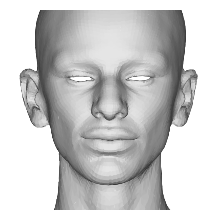

100%|██████████| 11248/11248 [08:47<00:00, 21.33it/s]


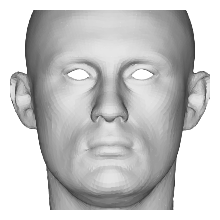

100%|██████████| 11248/11248 [08:45<00:00, 21.40it/s]


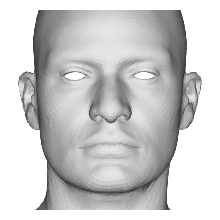

100%|██████████| 11248/11248 [09:05<00:00, 20.63it/s]


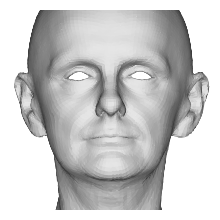

100%|██████████| 11248/11248 [08:28<00:00, 22.10it/s]


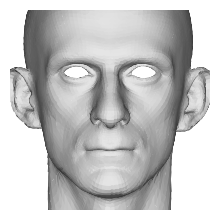

100%|██████████| 11248/11248 [08:55<00:00, 21.01it/s]


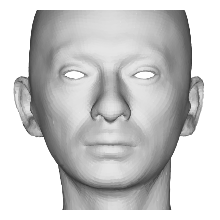

100%|██████████| 11248/11248 [09:04<00:00, 20.65it/s]


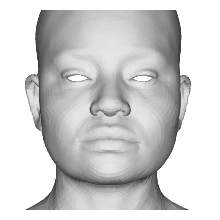

100%|██████████| 11248/11248 [08:37<00:00, 21.75it/s]


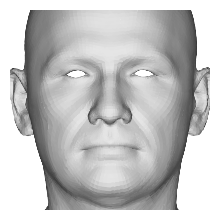

100%|██████████| 11248/11248 [08:51<00:00, 21.17it/s]


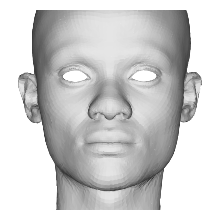

100%|██████████| 11248/11248 [08:46<00:00, 21.37it/s]


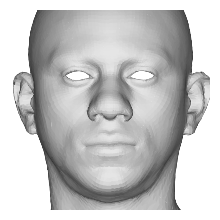

100%|██████████| 11248/11248 [09:17<00:00, 20.17it/s]


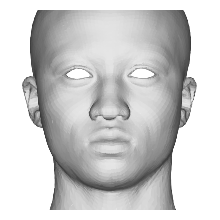

100%|██████████| 11248/11248 [09:07<00:00, 20.56it/s]


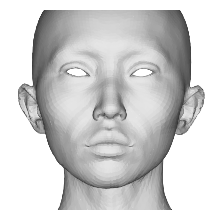

100%|██████████| 11248/11248 [09:04<00:00, 20.67it/s]


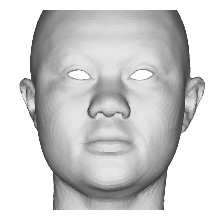

100%|██████████| 11248/11248 [08:31<00:00, 21.98it/s]


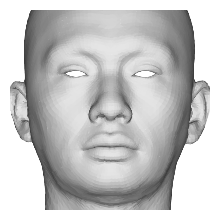

100%|██████████| 11248/11248 [09:11<00:00, 20.41it/s]


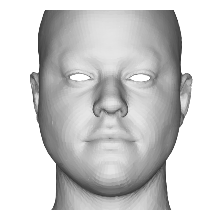

100%|██████████| 11248/11248 [09:10<00:00, 20.42it/s]


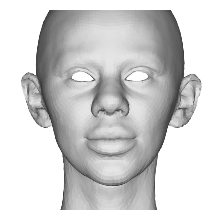

100%|██████████| 11248/11248 [08:59<00:00, 20.85it/s]


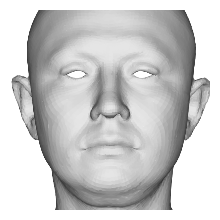

100%|██████████| 11248/11248 [08:45<00:00, 21.40it/s]


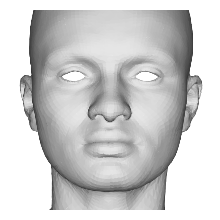

100%|██████████| 11248/11248 [09:08<00:00, 20.49it/s]


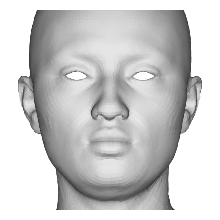

100%|██████████| 11248/11248 [08:28<00:00, 22.11it/s]


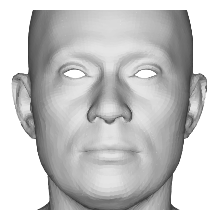

100%|██████████| 11248/11248 [08:33<00:00, 21.90it/s]


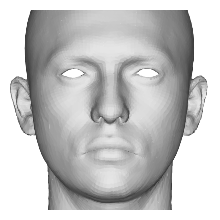

100%|██████████| 11248/11248 [08:25<00:00, 22.23it/s]


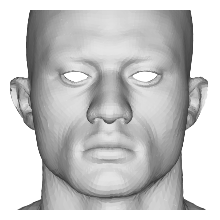

100%|██████████| 11248/11248 [08:30<00:00, 22.05it/s]


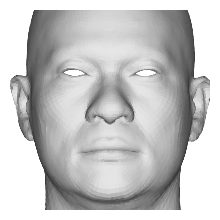

100%|██████████| 11248/11248 [08:52<00:00, 21.11it/s]


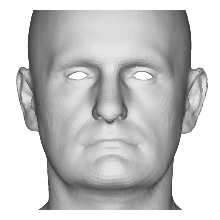

100%|██████████| 11248/11248 [08:57<00:00, 20.91it/s]


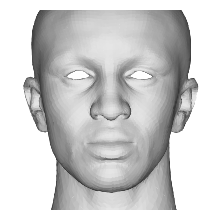

100%|██████████| 11248/11248 [08:42<00:00, 21.53it/s]


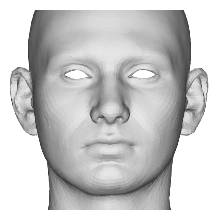

100%|██████████| 11248/11248 [09:19<00:00, 20.11it/s]


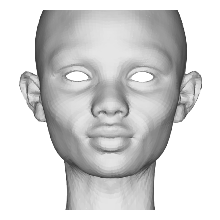

100%|██████████| 11248/11248 [09:10<00:00, 20.45it/s]


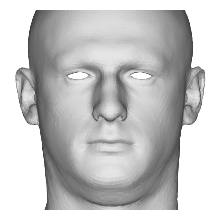

100%|██████████| 11248/11248 [08:49<00:00, 21.23it/s]


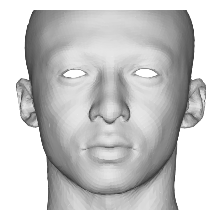

100%|██████████| 11248/11248 [09:20<00:00, 20.06it/s]


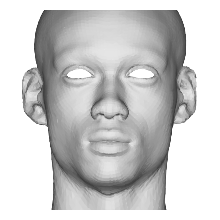

100%|██████████| 11248/11248 [08:53<00:00, 21.08it/s]


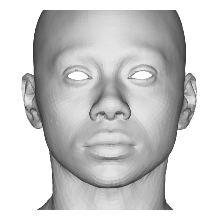

100%|██████████| 11248/11248 [09:04<00:00, 20.66it/s]


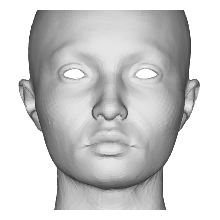

100%|██████████| 11248/11248 [08:55<00:00, 20.99it/s]


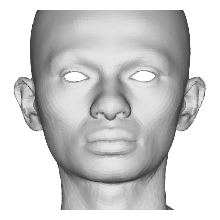

100%|██████████| 11248/11248 [09:03<00:00, 20.68it/s]


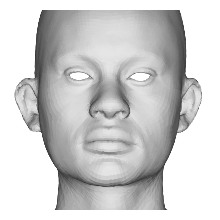

100%|██████████| 11248/11248 [09:05<00:00, 20.63it/s]


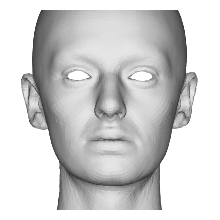

100%|██████████| 11248/11248 [08:18<00:00, 22.55it/s]


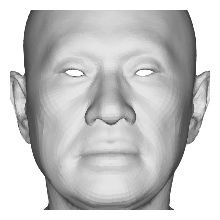

100%|██████████| 11248/11248 [08:33<00:00, 21.90it/s]


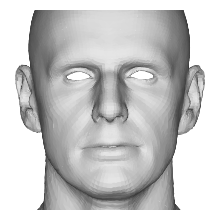

100%|██████████| 11248/11248 [08:23<00:00, 22.35it/s]


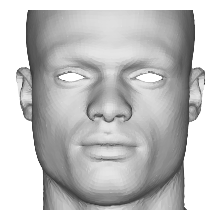

100%|██████████| 11248/11248 [09:15<00:00, 20.26it/s]


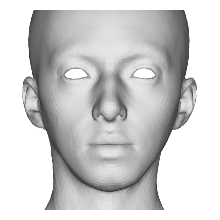

100%|██████████| 11248/11248 [08:48<00:00, 21.28it/s]


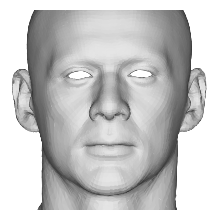

100%|██████████| 11248/11248 [09:01<00:00, 20.78it/s]


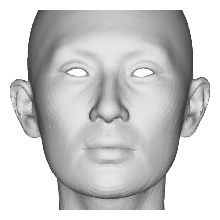

100%|██████████| 11248/11248 [09:11<00:00, 20.40it/s]


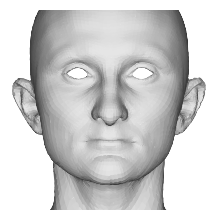

100%|██████████| 11248/11248 [08:50<00:00, 21.20it/s]


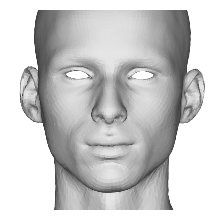

100%|██████████| 11248/11248 [08:55<00:00, 21.02it/s]


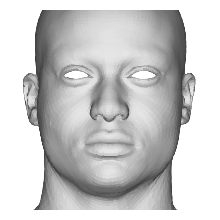

100%|██████████| 11248/11248 [09:06<00:00, 20.58it/s]


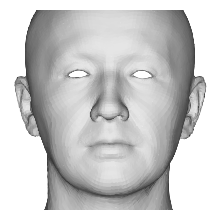

100%|██████████| 11248/11248 [08:46<00:00, 21.37it/s]


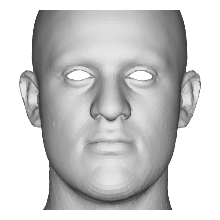

100%|██████████| 11248/11248 [09:13<00:00, 20.32it/s]


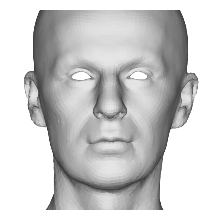

100%|██████████| 11248/11248 [08:40<00:00, 21.62it/s]


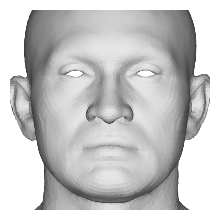

100%|██████████| 11248/11248 [09:04<00:00, 20.66it/s]


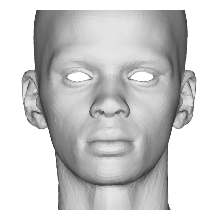

100%|██████████| 11248/11248 [08:54<00:00, 21.05it/s]


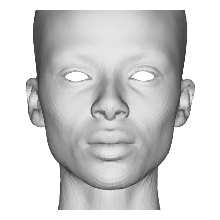

100%|██████████| 11248/11248 [08:50<00:00, 21.18it/s]


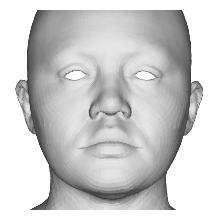

100%|██████████| 11248/11248 [09:21<00:00, 20.03it/s]


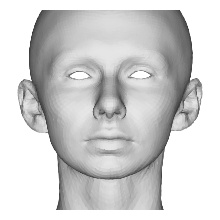

100%|██████████| 11248/11248 [08:44<00:00, 21.46it/s]


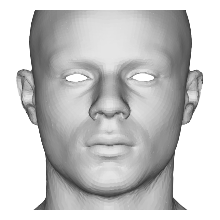

100%|██████████| 11248/11248 [09:11<00:00, 20.38it/s]


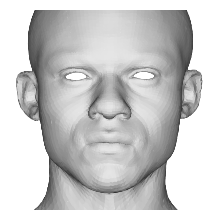

100%|██████████| 11248/11248 [09:04<00:00, 20.67it/s]


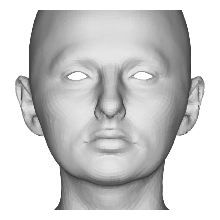

100%|██████████| 11248/11248 [08:45<00:00, 21.41it/s]


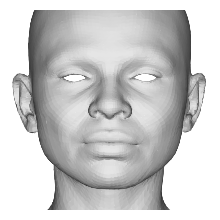

100%|██████████| 11248/11248 [08:59<00:00, 20.85it/s]


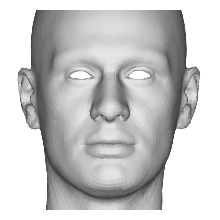

100%|██████████| 11248/11248 [08:57<00:00, 20.91it/s]


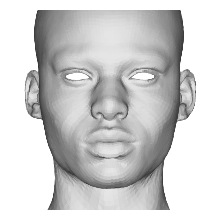

100%|██████████| 11248/11248 [08:54<00:00, 21.05it/s]


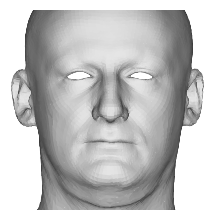

100%|██████████| 11248/11248 [09:08<00:00, 20.51it/s]


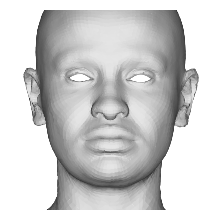

100%|██████████| 11248/11248 [08:50<00:00, 21.21it/s]


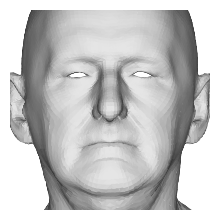

100%|██████████| 11248/11248 [08:45<00:00, 21.41it/s]


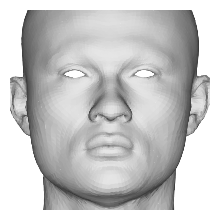

100%|██████████| 11248/11248 [08:35<00:00, 21.84it/s]


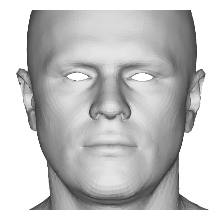

100%|██████████| 11248/11248 [09:31<00:00, 19.67it/s]


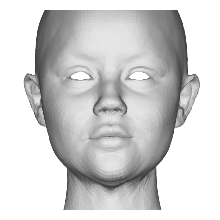

100%|██████████| 11248/11248 [09:19<00:00, 20.11it/s]


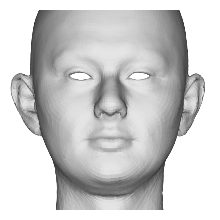

100%|██████████| 11248/11248 [09:20<00:00, 20.06it/s]


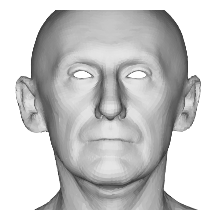

100%|██████████| 11248/11248 [08:41<00:00, 21.57it/s]


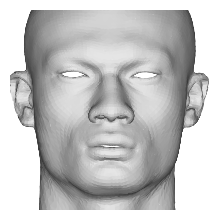

100%|██████████| 11248/11248 [08:46<00:00, 21.34it/s]


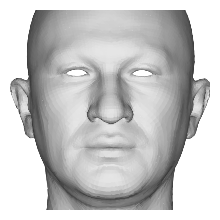

100%|██████████| 11248/11248 [08:36<00:00, 21.76it/s]


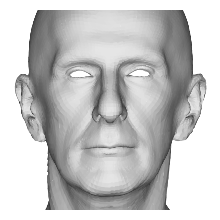

100%|██████████| 11248/11248 [08:35<00:00, 21.81it/s]


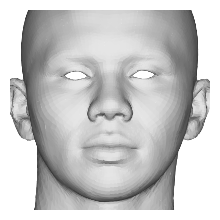

100%|██████████| 11248/11248 [08:52<00:00, 21.13it/s]


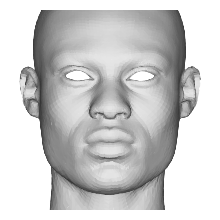

100%|██████████| 11248/11248 [09:03<00:00, 20.71it/s]


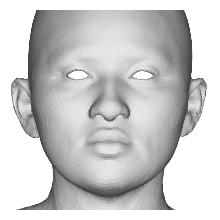

100%|██████████| 11248/11248 [09:02<00:00, 20.75it/s]


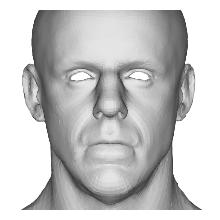

100%|██████████| 11248/11248 [08:56<00:00, 20.97it/s]


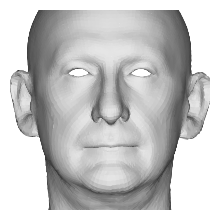

100%|██████████| 11248/11248 [09:05<00:00, 20.62it/s]


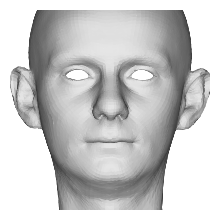

100%|██████████| 11248/11248 [09:31<00:00, 19.69it/s]


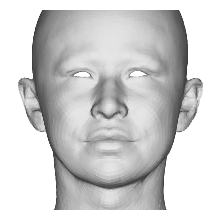

100%|██████████| 11248/11248 [09:34<00:00, 19.56it/s]


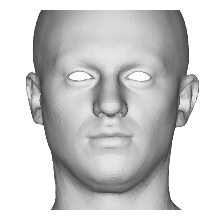

100%|██████████| 11248/11248 [08:45<00:00, 21.40it/s]


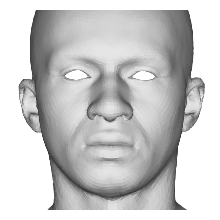

100%|██████████| 11248/11248 [09:14<00:00, 20.29it/s]


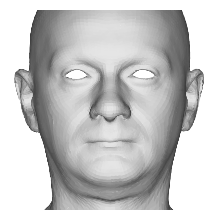

100%|██████████| 11248/11248 [08:33<00:00, 21.91it/s]


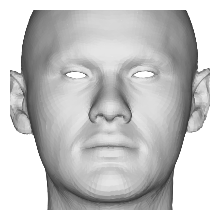

100%|██████████| 11248/11248 [08:49<00:00, 21.25it/s]


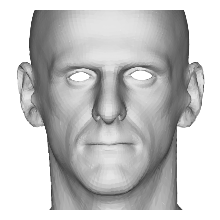

100%|██████████| 11248/11248 [09:01<00:00, 20.79it/s]


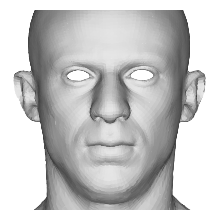

100%|██████████| 11248/11248 [08:36<00:00, 21.77it/s]


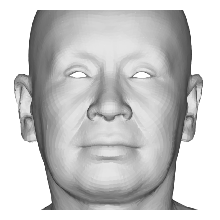

100%|██████████| 11248/11248 [09:26<00:00, 19.85it/s]


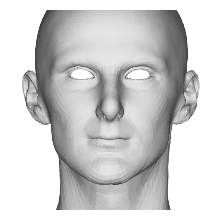

100%|██████████| 11248/11248 [09:21<00:00, 20.05it/s]


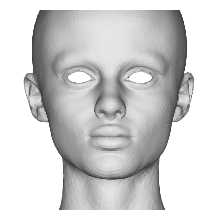

100%|██████████| 11248/11248 [08:58<00:00, 20.89it/s]


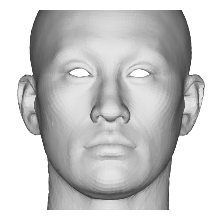

100%|██████████| 11248/11248 [08:53<00:00, 21.07it/s]


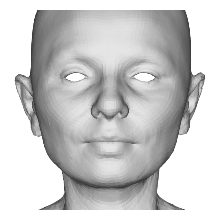

100%|██████████| 11248/11248 [08:50<00:00, 21.22it/s]


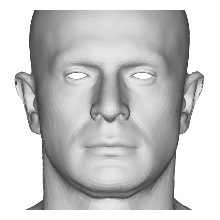

100%|██████████| 11248/11248 [09:11<00:00, 20.40it/s]


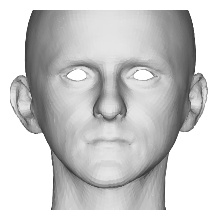

100%|██████████| 11248/11248 [09:02<00:00, 20.75it/s]


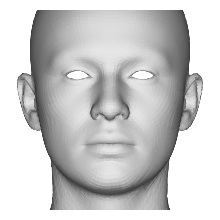

100%|██████████| 11248/11248 [10:07<00:00, 18.50it/s]


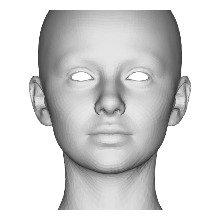

100%|██████████| 11248/11248 [09:05<00:00, 20.60it/s]


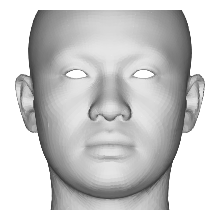

100%|██████████| 11248/11248 [09:02<00:00, 20.73it/s]


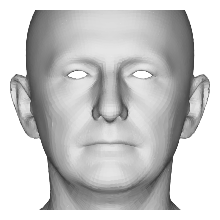

100%|██████████| 11248/11248 [08:52<00:00, 21.12it/s]


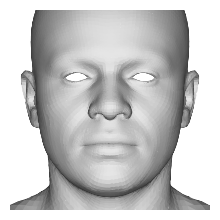

100%|██████████| 11248/11248 [08:59<00:00, 20.83it/s]


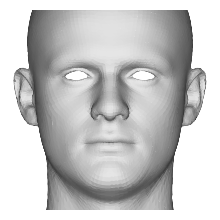

100%|██████████| 11248/11248 [08:58<00:00, 20.90it/s]


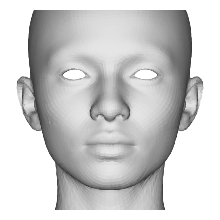

100%|██████████| 11248/11248 [09:01<00:00, 20.78it/s]


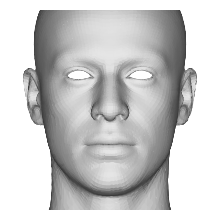

100%|██████████| 11248/11248 [09:00<00:00, 20.82it/s]


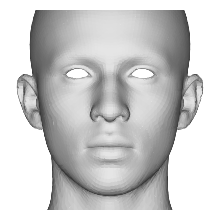

100%|██████████| 11248/11248 [09:12<00:00, 20.35it/s]


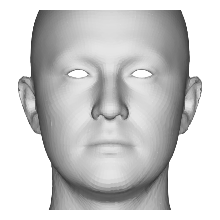

100%|██████████| 11248/11248 [09:01<00:00, 20.78it/s]


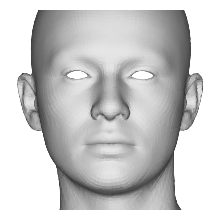

In [13]:
import pickle
from utils.keys import ict_data_synth

# mode = 'train'

data_name_list = ['voca','biwi','mf_SEN','coma','mf_ROM','ict','ict-cap','ict-synth'] # 0 1 2 3 4 5 6 7

SRC_SELECT_DATA=7
src_selection = data_name_list[SRC_SELECT_DATA]
src_dataset = EvalDataset(data_name='ict', toggle=False) # if eve-s01

data_ids = ict_data_synth['train']
num_ids = len(data_ids)
print(num_ids)

save_path ='/data/sihun/pca/ICT'
gd_save_path = os.path.join(save_path, 'geodesics')
os.makedirs(gd_save_path, exist_ok=True)

for n_id in range(num_ids):
    SRC_SELECT_MESH=n_id
    id_name = data_ids[n_id]
    id_save_file_path = os.path.join(gd_save_path, id_name+'.pkl')
    
    if os.path.exists(id_save_file_path):
        continue    
    src_v, src_f = get_mesh(src_selection, src_dataset, SRC_SELECT_MESH)
    
    src_v_th = torch.from_numpy(src_v)
    src_f_th = torch.from_numpy(src_f)

    geodistances_all = cal_geodesic_distance_for_all(
        src_v_th, src_f_th, max_distance=0.5
    )
    
    v_list=[src_v]
    f_list=[src_f]
    plot_image_array(
        v_list, f_list,
        rot_list=[[0,0,0]]*len(v_list),
        size=2, bg_black=False, mode='shade', save=False
    )

    id_save_file_path = os.path.join(gd_save_path, id_name+'.pkl')
    with open(id_save_file_path, 'wb') as f:
        pickle.dump(geodistances_all, f)
    # break

torch.Size([11248, 11248])
torch.Size([11248, 11248])


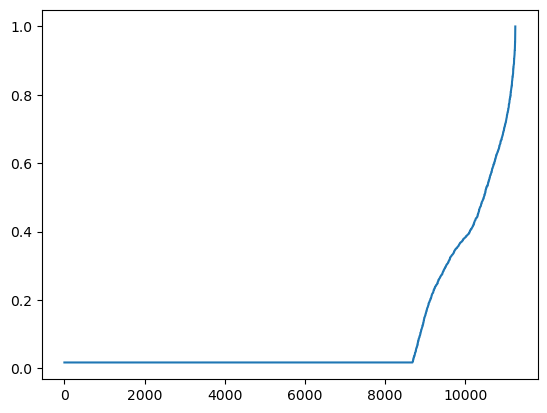

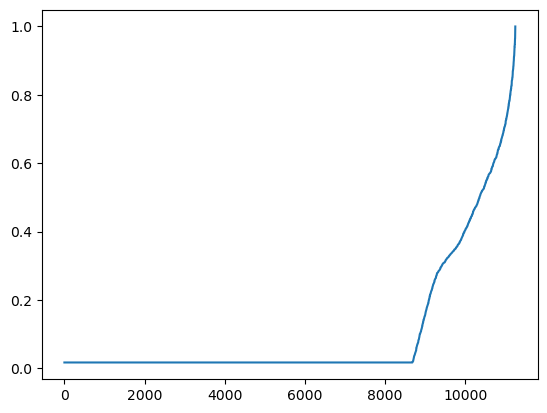

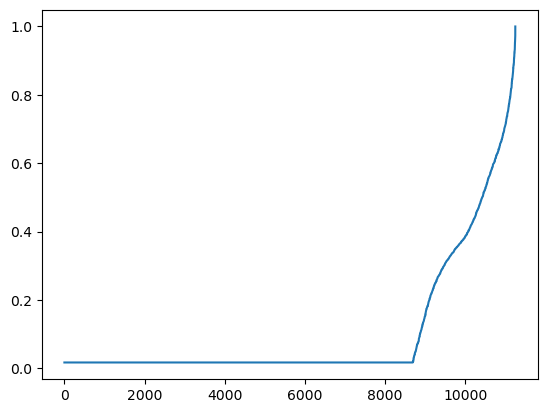

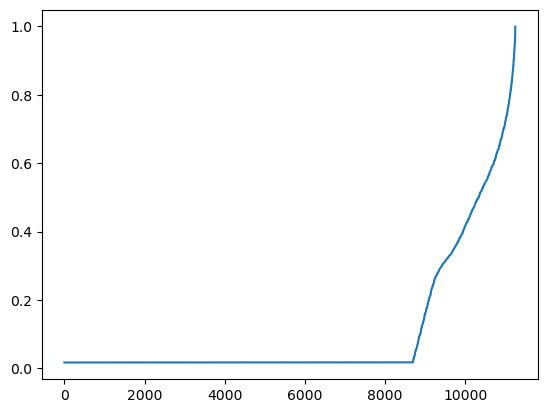

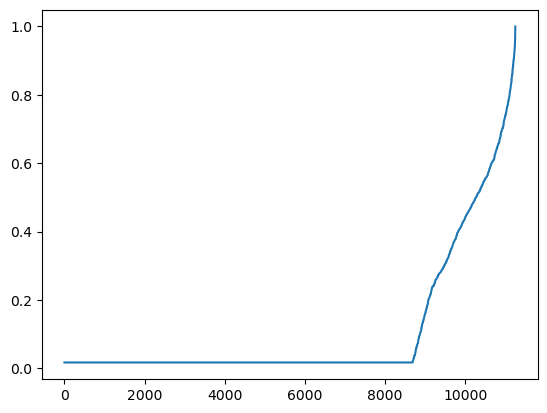

In [56]:
print(distances.shape)
asd = distances.transpose(1,0).squeeze()
print(asd.shape)
# asd = np.sort(asd, 0)

for i in range(5):
    asdasd = np.sort(asd[:, i], 0)
    plt.plot(asdasd)
    plt.show()

In [2]:
# import torch
# asd= torch.rand(3,3).requires_grad_(True)
# optimizer = torch.optim.AdamW(
#             [asd],
#             lr=2E-4,
#             betas=(0.9, 0.999)
#         )

# scheduler = torch.optim.lr_scheduler.StepLR(
#             optimizer, 
#             step_size=20,
#             gamma=0.95
#         )
# for i in range(200):
#     optimizer.step()
#     scheduler.step()
#     if i % 20 == 0:
#         print(i, scheduler.get_lr())
# # 2E-4 --sc_step 20
# # self.scheduler.step()
# # epoch % self.opts.sc_step

In [3]:
# import numpy as np
# import matplotlib.pyplot as plt

# expression_vecs2 = np.load(f'../data/ICT_live_100/expression_vecs_val.npy')
# asd = np.load('../ict_face_pt/random_expression_vecs.npy')
# expression_vecs = np.r_[asd, expression_vecs2]
# plt.imshow(expression_vecs, interpolation='nearest', aspect='auto')


## visuals

In [4]:
def get_mesh(selection, dataset, SELECT_MESH):
    if selection=='ict'or selection=='ict-cap':
        # id_vecs = np.load(f'{__abs_path__}/data/ICT_live_100/iden_vecs.npy')
        # id_vecs = np.load(f'{__abs_path__}/ict_face_pt/random_identity_vecs.npy')[:101]
        id_vecs = torch.load(f'{__abs_path__}/ict_face_pt/ict_id_vecs_test.pt').numpy()
        id_disps = dataset.ict_face_model.get_id_disp(id_vecs[SELECT_MESH])
        mesh_v = dataset.ict_face_model.neutral_verts.squeeze() + id_disps.squeeze()
        
        return mesh_v, dataset.ict_face_model.faces
    elif selection=='ict-synth':
        
        id_vecs = np.load(f'{__abs_path__}/ict_face_pt/random_identity_vecs.npy')[:111]
        id_disps = dataset.ict_face_model.get_id_disp(id_vecs[SELECT_MESH])
        mesh_v = dataset.ict_face_model.neutral_verts.squeeze() + id_disps.squeeze()
        
        return mesh_v, dataset.ict_face_model.faces
    else:
        if selection=='voca':
            mesh = dataset.voca_mesh
        elif selection=='biwi':
            # mesh = dataset.biwi_mesh            
            biwi_trimesh = trimesh.load(f'{__abs_path__}/test-mesh/BIWI.ply')
            with open(f'{__abs_path__}/test-mesh/biwi_templates.pkl', 'rb') as f:
                mesh = pickle.load(f)
                
            mesh['face']=biwi_trimesh.faces
        elif selection=='mf_SEN':
            mesh = dataset.mf_SEN_mesh
        elif selection=='coma':
            mesh = dataset.coma_mesh
        elif selection=='mf_ROM':
            mesh = dataset.mf_ROM_mesh

        mesh_list = [idname for idname in mesh.keys() if idname!='face']
        mesh_v = mesh[mesh_list[SELECT_MESH]]

        if selection=='biwi':
            m_align = np.load(f'{__abs_path__}/utils/biwi/align.npy')
            mesh_v = np.concatenate((mesh_v,np.ones((mesh_v.shape[0],1))), axis=1) @ m_align.T
        return mesh_v, mesh['face']

mf ROM data list exists: /source/sihun/NeuralFacialAnimation/utils/data/mf_ROM_vertex_data_test.txt


## vis play

In [10]:
data_name_list = ['voca','biwi','mf_SEN','coma','mf_ROM','ict','ict-cap'] # 0 1 2 3 4 5 6

SRC_SELECT_DATA=4
SRC_SELECT_MESH=12
# SRC_SELECT_DATA=5
# SRC_SELECT_MESH=0
EXP_NUM=0

TGT_SELECT_DATA=4
TGT_SELECT_mesh=12
# TGT_SELECT_DATA=5
# TGT_SELECT_mesh=0

src_selection = data_name_list[SRC_SELECT_DATA]
tgt_selection = data_name_list[TGT_SELECT_DATA]

device='cuda:0'

src_dataset = EvalDataset(data_name=src_selection, toggle=False) # if eve-s01
src_v, src_f = get_mesh(src_selection, src_dataset, SRC_SELECT_MESH)
src_n = igl.per_vertex_normals(src_v, src_f)

tgt_dataset = EvalDataset(data_name=tgt_selection, toggle=False) # if eve-s01
tgt_v, tgt_f = get_mesh(tgt_selection, tgt_dataset, TGT_SELECT_mesh)
tgt_n = igl.per_vertex_normals(tgt_v, tgt_f)


mf ROM data list exists: /source/sihun/NeuralFacialAnimation/utils/data/mf_ROM_vertex_data_test.txt
mf ROM data list exists: /source/sihun/NeuralFacialAnimation/utils/data/mf_ROM_vertex_data_test.txt


In [12]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import widgets
from IPython.display import display, Javascript

SAVE=0
SIZE=3
button=False
M_SCALE=0.6
M_SCALE_zoom=1.5
M_TRANS_zoom=np.array([0,0.52,0])

# 파일 리스트들
# paths_GT = sorted(glob('/source/sihun/NeuralFacialAnimation/eval_CBD/GT-ict_test-to-ict_test/*.npy'))
paths_GT = sorted(glob('/source/sihun/NeuralFacialAnimation/eval_CBD/GT-mf_ROM_test-to-mf_ROM_test/*.npy'))
# data_name = 'ict'
data_name = 'mf_ROM'

# paths_v0 = sorted(glob('/source/sihun/NeuralFacialAnimation/eval_CBD/2024-08-18-23-32-29-all-eval/ict-masked-laplacian/verts/*.npy'))
# paths_v1 = sorted(glob(f'/source/sihun/NeuralFacialAnimation/eval_CBD/2026-01-13-14-02-16-NGBCv5-sqrelu-eval/ict-masked-laplacian/verts/*.npy'))
# paths_v2 = sorted(glob(f'/source/sihun/NeuralFacialAnimation/eval_CBD/2026-02-25-17-14-34-NGBCv5-eval/ict-masked-laplacian/verts/*.npy'))


paths_v0 = sorted(glob(f'/source/sihun/NeuralFacialAnimation/eval_CBD/2024-08-18-23-32-29-all-eval/mf_ROM-masked-laplacian/verts/*.npy'))
paths_v1 = sorted(glob(f'/source/sihun/NeuralFacialAnimation/eval_CBD/2026-01-13-14-02-16-NGBCv5-sqrelu-eval/mf_ROM-masked-laplacian/verts/*.npy'))
paths_v2 = sorted(glob(f'/source/sihun/NeuralFacialAnimation/eval_CBD/2026-02-25-17-14-34-NGBCv5-eval/mf_ROM-masked-laplacian/verts/*.npy'))
paths_v3 = sorted(glob(f'/source/sihun/NeuralFacialAnimation/eval_CBD/2025-11-09-21-21-43-NGBCv5-eval/mf_ROM-masked/verts/*.npy'))

len_mesh_file_paths = len(paths_GT)

print(len(paths_GT))
print(len(paths_v0))
print(len(paths_v1))
print(len(paths_v2))
# print(len(paths_v3))
# print(len(paths_v4))

# --- 업데이트 함수: frame만 사용, y_rot/save 무시 ---
def update_frame(frame):
    plt.close()

    v_list = [
        np.load(paths_GT[frame]).squeeze(),
        np.load(paths_v0[frame]).squeeze(),
        np.load(paths_v1[frame]).squeeze(),
        np.load(paths_v2[frame]).squeeze(),
        np.load(paths_v3[frame]).squeeze(),
    ]
    v_list = [v * M_SCALE for v in v_list]
    f_list = [tgt_f]*len(v_list)

    # y 회전/저장 옵션은 무시
    plot_image_array(
        v_list, f_list,
        rot_list=[[0,0,0]]*len(v_list),
        size=SIZE, bg_black=False, mode='shade', save=False
    )
    # plot_image_array_diff2(
    #     v_list, f_list, v_list[0],
    #     rot_list=[[0,0,0]]*len(v_list),
    #     size=SIZE, bg_black=False, mode='shade', save=False
    # )

# --- 위젯: Play + Slider 링크 ---
frame_slider = widgets.IntSlider(
    value=0, min=0, max=max(len_mesh_file_paths-1, 0), step=1,
    description='frame', continuous_update=False, readout=True
)
play = widgets.Play(
    value=0, min=0, max=max(len_mesh_file_paths-1, 0), step=1,
    interval=1000,  # ms per frame (원하면 조절)
    description="Press play", disabled=False
)

# 양방향 링크
widgets.jslink((play, 'value'), (frame_slider, 'value'))

# 출력 영역과 연결
out = widgets.interactive_output(update_frame, {'frame': frame_slider})

# UI 배치
ui = widgets.VBox([
    widgets.HBox([play, frame_slider]),
    out
])
display(ui)

# --- 자동 재생 트리거 (노트북에서 셀 실행 시 자동 Play 버튼 클릭) ---
# 브라우저/테마에 따라 실패할 수 있어요. 그 경우 수동으로 Play 클릭하세요.
display(Javascript("""
setTimeout(function(){
  const btn = document.querySelector('button.jupyter-widgets.widget-play');
  if (btn) btn.click();
}, 300);
"""))


11649
11649
11649
11649


<IPython.core.display.Javascript object>

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import widgets
from IPython.display import display, Javascript

SAVE=0
SIZE=3
button=False
M_SCALE=0.6
M_SCALE_zoom=1.5
M_TRANS_zoom=np.array([0,0.52,0])

# 파일 리스트들
paths_GT = sorted(glob('/source/sihun/NeuralFacialAnimation/eval_CBD/GT-mf_ROM_test-to-mf_ROM_test/*.npy'))
# paths_GT = sorted(glob('/source/sihun/NeuralFacialAnimation/eval_CBD/GT-ict_test-to-ict_test/*.npy'))
# data_name = 'ict'
data_name = 'mf_ROM'

# paths_v9 = sorted(glob('../vis_CBD/2025-10-09-02-04-49-NGBCv5/mf_ROM_test-to-mf_ROM_test-masked/verts/*.npy'))
# paths_v0 = sorted(glob('../vis_CBD/2025-10-22-22-30-30-NGBCv5/mf_ROM_test-to-mf_ROM_test-masked/verts/*.npy'))
# paths_v0 = sorted(glob('../vis_CBD/2025-11-03-14-56-32-NGBCv5/mf_ROM_test-to-mf_ROM_test-masked/verts/*.npy'))
paths_va = sorted(glob(f'/source/sihun/NeuralFacialAnimation/eval_CBD/2025-10-22-22-30-30-NGBCv5-eval/{data_name}-masked/verts/*.npy'))
# paths_v0 = sorted(glob('/source/sihun/NeuralFacialAnimation/eval_CBD/2025-11-05-16-32-53-NGBCv5-eval/mf_ROM-masked/verts/*.npy'))
# paths_v0 = sorted(glob(f'/source/sihun/NeuralFacialAnimation/eval_CBD/2025-11-09-21-21-43-NGBCv5-50-eval/{data_name}-masked/verts/*.npy'))
paths_v0 = sorted(glob(f'/source/sihun/NeuralFacialAnimation/eval_CBD/2025-11-09-21-21-43-NGBCv5-eval/{data_name}-masked/verts/*.npy'))

# paths_v1 = sorted(glob('../vis_CBD/2024-07-08-06-27-12-all-NFS/mf_ROM_test-to-mf_ROM_test-masked/verts/*.npy'))
# paths_v2 = sorted(glob('../vis_CBD/2024-08-18-23-32-29-all/mf_ROM_test-to-mf_ROM_test-masked/verts/*.npy'))

# paths_v2 = sorted(glob('../eval_CBD/2024-08-18-23-32-29-all/mf_ROM_test-to-mf_ROM_test/*.npy')) # NFS
# paths_v3 = sorted(glob('../vis_CBD/exp_019_ICT_MF-jacob_NFR/mf_ROM_test-to-mf_ROM_test-masked/verts/*.npy')) NFR

paths_v2 = sorted(glob(f'/source/sihun/NeuralFacialAnimation/eval_CBD/2024-08-18-23-32-29-all-eval/{data_name}-masked/verts/*.npy'))
# paths_v3 = sorted(glob(f'/source/sihun/NeuralFacialAnimation/eval_CBD/nfr/ict_test-to-ict_test/*.npy'))
# paths_v2 = sorted(glob(f'/source/sihun/NeuralFacialAnimation/vis_CBD/nfs/mf_ROM_test-to-mf_ROM_test/*.npy'))
paths_v3 = sorted(glob(f'/source/sihun/NeuralFacialAnimation/vis_CBD/nfr/mf_ROM_test-to-mf_ROM_test/*.npy'))

# paths_v4 = sorted(glob('../eval_CBD/2025-10-20-00-15-40-CBD-eval/mf_ROM-masked/verts/*.npy'))
paths_v4 = sorted(glob(f'/source/sihun/NeuralFacialAnimation/eval_CBD/2025-10-20-00-15-40-CBD-eval/{data_name}-masked/verts/*.npy'))
len_mesh_file_paths = len(paths_GT)

print(len(paths_GT))
print(len(paths_v0))
# print(len(paths_v1))
print(len(paths_v2))
print(len(paths_v3))
# print(len(paths_v4))

# --- 업데이트 함수: frame만 사용, y_rot/save 무시 ---
def update_frame(frame):
    plt.close()

    v_list = [
        np.load(paths_GT[frame]).squeeze(),
        np.load(paths_v0[frame]).squeeze(),
        # np.load(paths_va[frame]).squeeze(),
        # np.load(paths_v9[frame]).squeeze(),
        # np.load(paths_v1[frame]).squeeze(),
        np.load(paths_v2[frame]).squeeze(), # NFS
        np.load(paths_v3[frame]).squeeze(), # NFR
        np.load(paths_v4[frame]).squeeze(), # NC
    ]
    v_list = [v * M_SCALE for v in v_list]
    f_list = [tgt_f]*len(v_list)

    # y 회전/저장 옵션은 무시
    plot_image_array(
        v_list, f_list,
        rot_list=[[0,0,0]]*len(v_list),
        size=SIZE, bg_black=False, mode='shade', save=False
    )
    # plot_image_array_diff2(
    #     v_list, f_list, v_list[0],
    #     rot_list=[[0,0,0]]*len(v_list),
    #     size=SIZE, bg_black=False, mode='shade', save=False
    # )

# --- 위젯: Play + Slider 링크 ---
frame_slider = widgets.IntSlider(
    value=0, min=0, max=max(len_mesh_file_paths-1, 0), step=1,
    description='frame', continuous_update=False, readout=True
)
play = widgets.Play(
    value=0, min=0, max=max(len_mesh_file_paths-1, 0), step=1,
    interval=1000,  # ms per frame (원하면 조절)
    description="Press play", disabled=False
)

# 양방향 링크
widgets.jslink((play, 'value'), (frame_slider, 'value'))

# 출력 영역과 연결
out = widgets.interactive_output(update_frame, {'frame': frame_slider})

# UI 배치
ui = widgets.VBox([
    widgets.HBox([play, frame_slider]),
    out
])
display(ui)

# --- 자동 재생 트리거 (노트북에서 셀 실행 시 자동 Play 버튼 클릭) ---
# 브라우저/테마에 따라 실패할 수 있어요. 그 경우 수동으로 Play 클릭하세요.
display(Javascript("""
setTimeout(function(){
  const btn = document.querySelector('button.jupyter-widgets.widget-play');
  if (btn) btn.click();
}, 300);
"""))


11649
11649
11649
11649


<IPython.core.display.Javascript object>

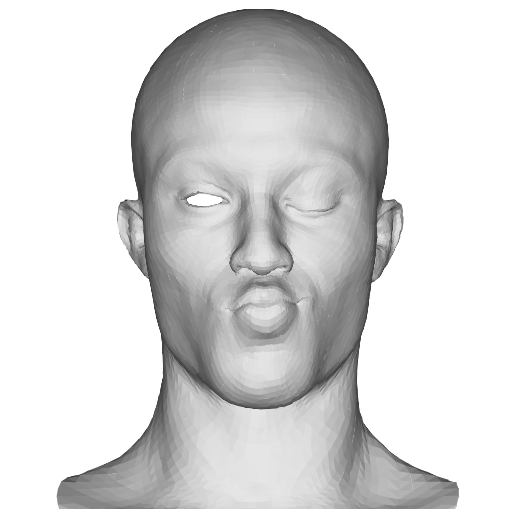

In [158]:
v_list = [
    np.load(paths_v0[1485]).squeeze(),
]
# v_list = [v * 1.5  + np.array([0,.05,0]) for v in v_list]
v_list = [v * 0.67 for v in v_list]
f_list = [tgt_f]*len(v_list)

# y 회전/저장 옵션은 무시
plot_image_array(
    v_list, f_list,
    rot_list=[[0,0,0]]*len(v_list),
    size=5, bg_black=False, mode='shade', save=0
)

# vis resu;t

In [5]:
data_name_list = ['voca','biwi','mf_SEN','coma','mf_ROM','ict','ict-cap'] # 0 1 2 3 4 5 6

SRC_SELECT_DATA=4
SRC_SELECT_MESH=12
EXP_NUM=0

TGT_SELECT_DATA=4
TGT_SELECT_mesh=12

src_selection = data_name_list[SRC_SELECT_DATA]
tgt_selection = data_name_list[TGT_SELECT_DATA]

device='cuda:0'

src_dataset = EvalDataset(data_name=src_selection, toggle=False) # if eve-s01
src_v, src_f = get_mesh(src_selection, src_dataset, SRC_SELECT_MESH)
src_n = igl.per_vertex_normals(src_v, src_f)

tgt_dataset = EvalDataset(data_name=tgt_selection, toggle=False) # if eve-s01
tgt_v, tgt_f = get_mesh(tgt_selection, tgt_dataset, TGT_SELECT_mesh)
tgt_n = igl.per_vertex_normals(tgt_v, tgt_f)


mf ROM data list exists: /source/sihun/NeuralFacialAnimation/utils/data/mf_ROM_vertex_data_test.txt
mf ROM data list exists: /source/sihun/NeuralFacialAnimation/utils/data/mf_ROM_vertex_data_test.txt


In [13]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import widgets
from IPython.display import display, Javascript


SAVE=0
SIZE=4
button=False
M_SCALE=0.6
M_TRNS = np.array([0,0,0])
M_SCALE_zoom=1.5
M_TRANS_zoom=np.array([0,0.52,0])
rot_list=[[0,0,0]]

# gt_data_name = 'GT-ict-cap_test-to-ict-cap_test_01'
# data_name = 'ict-cap-ID_000_test-to-ict-cap-ID_000_test_01'
# data_name = 'ict-cap-ID_000_test-to-ict-cap-ID_003_test_01'
# data_name = 'ict-cap-ID_000_test-to-mf_ROM-ID_012_test_01'

# gt_data_name = 'GT-ict-cap_test-to-ict-cap_test_00'
# data_name = 'ict-cap-ID_002_test-to-ict-cap-ID_002_test_00'
# data_name = 'ict-cap-ID_002_test-to-ict-cap-ID_000_test_00'
# data_name = 'ict-cap-ID_002_test-to-mf_ROM-ID_012_test_00'


gt_data_name = 'GT-mf_ROM_test-to-mf_ROM_test_00'
data_name = 'mf_ROM_test-to-mf_ROM_test'
# data_name = 'mf_ROM_test-to-mf_ROM_train'
# data_name = 'mf_ROM_test-to-ict-cap_test-ID_000'
# data_name = 'mf_ROM_test-to-ict-cap_test-ID_009'

# scp -r -P 30277 root@143.248.249.98:/source/sihun/NeuralFacialAnimation/eval_CBD/nfr /source/sihun/NeuralFacialAnimation/vis_CBD/nfr
# scp -r -P 30277 root@143.248.249.98:/source/sihun/NeuralFacialAnimation/eval_CBD/nfs /source/sihun/NeuralFacialAnimation/vis_CBD/nfs

# 파일 리스트들
paths_GT = sorted(glob(f'../vis_CBD/{gt_data_name}/*.npy'))
paths_v9 = sorted(glob(f'../vis_CBD/2025-10-09-02-04-49-NGBCv5/{data_name}-masked/verts/*.npy'))
# paths_v0 = sorted(glob(f'../vis_CBD/2025-10-22-22-30-30-NGBCv5/{data_name}-masked/verts/*.npy'))
# paths_v0 = sorted(glob(f'../vis_CBD/2025-11-03-14-56-32-NGBCv5/{data_name}-masked/verts/*.npy'))
# paths_v0 = sorted(glob(f'../vis_CBD/2025-11-05-16-32-53-NGBCv5-best/{data_name}-masked/verts/*.npy'))
# paths_v0 = sorted(glob(f'../vis_CBD/2025-11-05-16-32-53-NGBCv5-150/{data_name}-masked/verts/*.npy'))
# paths_v0 = sorted(glob(f'../vis_CBD/2025-11-08-22-53-46-NGBCv5/{data_name}-masked/verts/*.npy'))
# paths_v0 = sorted(glob(f'../vis_CBD/2025-11-08-22-53-46-NGBCv5-best/{data_name}-masked/verts/*.npy'))
paths_v0 = sorted(glob(f'../vis_CBD/2025-11-09-21-21-43-NGBCv5-50/{data_name}-masked/verts/*.npy'))
# paths_v0 = sorted(glob('/source/sihun/NeuralFacialAnimation/eval_CBD/2025-11-09-21-21-43-NGBCv5-50-eval/mf_ROM-masked/verts/*.npy'))

# paths_v0 = sorted(glob(f'../eval_CBD/2025-11-08-22-53-46-NGBCv5-eval/mf_ROM-masked/verts/*.npy'))
# paths_v0 = sorted(glob(f'../eval_CBD/2025-11-08-22-53-46-NGBCv5-best-eval/mf_ROM-masked/verts/*.npy'))
# paths_v2 = sorted(glob(f'../vis_CBD/2024-07-08-06-27-12-all/{data_name}-masked/verts/*.npy'))
# paths_v2 = sorted(glob(f'../vis_CBD/2024-07-08-06-27-12-all-noisy/{data_name}-masked/verts/*.npy'))
# paths_v2 = sorted(glob(f'../vis_CBD/2024-08-18-23-32-29-all-prev/{data_name}-masked_/verts/*.npy'))
paths_v2 = sorted(glob(f'../vis_CBD/2024-08-18-23-32-29-all/{data_name}-masked/verts/*.npy'))
# paths_v2 = sorted(glob(f'../vis_CBD/nfs/{data_name}/*.npy'))

# paths_v3 = sorted(glob(f'../vis_CBD/exp_019_ICT_MF-jacob_NFR/{data_name}-masked/verts/*.npy'))
paths_v3 = sorted(glob(f'../vis_CBD/NFR/{data_name}-masked/verts/*.npy'))
# paths_v3 = sorted(glob(f'../vis_CBD/nfr/{data_name}/*.npy'))
# paths_v3 = sorted(glob(f'../eval_CBD/NFR-pretrained-eval/{data_name}-masked/verts/*.npy'))

paths_v4 = sorted(glob(f'../vis_CBD/2025-10-20-00-15-40-CBD/{data_name}-masked/verts/*.npy'))

paths_v5 = sorted(glob(f'../eval_CBD/2025-11-21-12-50-24-NGBCv1-800-eval/mf_ROM-masked/verts/*.npy'))
paths_v6 = sorted(glob(f'../eval_CBD/2025-11-26-14-46-32-NGBCv1-800-eval/mf_ROM-masked/verts/*.npy'))
paths_v7 = sorted(glob(f'../eval_CBD/2025-12-04-00-29-05-NGBCv1-800-eval/mf_ROM-masked/verts/*.npy'))

# paths_v2 = sorted(glob('../eval_CBD/2024-08-18-23-32-29-all-eval/mf_ROM-masked/verts/*.npy'))
# paths_v3 = sorted(glob('../eval_CBD/exp_019_ICT_MF-jacob_NFR-eval/mf_ROM-masked/verts/*.npy'))
# paths_v4 = sorted(glob('../eval_CBD/2025-10-20-00-15-40-CBD-eval/mf_ROM-masked/verts/*.npy'))

len_mesh_file_paths = len(paths_GT)

print(len(paths_GT))
print(len(paths_v0))
# print(len(paths_v1))
print(len(paths_v2))
print(len(paths_v3))
# print(len(paths_v4))

# --- 업데이트 함수: frame만 사용, y_rot/save 무시 ---
def update_frame(frame):
    plt.close()

    v_list = [
        np.load(paths_GT[frame]).squeeze(),        
        np.load(paths_v0[frame]).squeeze(),
        # np.load(paths_v9[frame]).squeeze(),
        # np.load(paths_v1[frame]).squeeze(),
        # np.load(paths_v2[frame]).squeeze(), # NFS
        # np.load(paths_v3[frame]).squeeze(), # NFR
        # np.load(paths_v4[frame]).squeeze(),
        np.load(paths_v5[frame]).squeeze(), 
        np.load(paths_v6[frame]).squeeze(), 
        np.load(paths_v7[frame]).squeeze(), 
    ]
    v_list = [v * M_SCALE for v in v_list]
    f_list = [src_f]+[tgt_f]*(len(v_list)-1)
    # f_list = [tgt_f]*len(v_list)

    # y 회전/저장 옵션은 무시
    plot_image_array(
        v_list, f_list,
        rot_list=[[0,0,0]]*len(v_list),
        size=SIZE, bg_black=False, mode='shade', save=False
    )
    # plot_mesh_gouraud(
    #     v_list, f_list, mesh_scale=M_SCALE, mesh_trans=M_TRNS,
    #     # is_diff=True, 
    #     # diff_base=v_list[0], # calculates difference based on this mesh
    #     # diff_base=src_v, # calculates difference based on this mesh
    #     backface_culling=True,
    #     rot_list=rot_list*len(v_list), size=SIZE, mode='shade', bg_black=False,
    #     # logdir='../_tmp',name='',save=False,
    # )

    # plot_image_array_diff2(
    #     v_list, f_list, 
    #     # v_list[0],
    #     src_v * M_SCALE,
    #     rot_list=[[0,0,0]]*len(v_list),
    #     size=SIZE, bg_black=False, mode='shade', save=False
    # )

# --- 위젯: Play + Slider 링크 ---
frame_slider = widgets.IntSlider(
    value=0, min=0, max=max(len_mesh_file_paths-1, 0), step=1,
    description='frame', continuous_update=False, readout=True
)
play = widgets.Play(
    value=0, min=0, max=max(len_mesh_file_paths-1, 0), step=1,
    interval=850,  # ms per frame (원하면 조절)
    description="Press play", disabled=False
)

# 양방향 링크
widgets.jslink((play, 'value'), (frame_slider, 'value'))

# 출력 영역과 연결
out = widgets.interactive_output(update_frame, {'frame': frame_slider})

# UI 배치
ui = widgets.VBox([
    widgets.HBox([play, frame_slider]),
    out
])
display(ui)

# --- 자동 재생 트리거 (노트북에서 셀 실행 시 자동 Play 버튼 클릭) ---
# 브라우저/테마에 따라 실패할 수 있어요. 그 경우 수동으로 Play 클릭하세요.
display(Javascript("""
setTimeout(function(){
  const btn = document.querySelector('button.jupyter-widgets.widget-play');
  if (btn) btn.click();
}, 300);
"""))


11649
11649
11649
11649


<IPython.core.display.Javascript object>

# single

In [38]:
data_name_list = ['voca','biwi','mf_SEN','coma','mf_ROM','ict','ict-cap'] # 0 1 2 3 4 5 6

SRC_SELECT_DATA=5
SRC_SELECT_MESH=0
EXP_NUM=0

TGT_SELECT_DATA=4
TGT_SELECT_mesh=12

src_selection = data_name_list[SRC_SELECT_DATA]
tgt_selection = data_name_list[TGT_SELECT_DATA]

device='cuda:0'

src_dataset = EvalDataset(data_name=src_selection, toggle=False) # if eve-s01
src_v, src_f = get_mesh(src_selection, src_dataset, SRC_SELECT_MESH)
src_n = igl.per_vertex_normals(src_v, src_f)

tgt_dataset = EvalDataset(data_name=tgt_selection, toggle=False) # if eve-s01
tgt_v, tgt_f = get_mesh(tgt_selection, tgt_dataset, TGT_SELECT_mesh)
tgt_n = igl.per_vertex_normals(tgt_v, tgt_f)


mf ROM data list exists: /source/sihun/NeuralFacialAnimation/utils/data/mf_ROM_vertex_data_test.txt


In [39]:
SAVE=0
SIZE=4
button=False
# rot_list=[[0,0,0]]
M_SCALE=0.6
M_SCALE_zoom=1.5
# M_TRANS_zoom=np.array([0,0.5,0])
M_TRANS_zoom=np.array([0,0.52,0])

# paths_GT = sorted(glob('/source/sihun/NeuralFacialAnimation/eval_CBD/GT-mf_ROM_test-to-mf_ROM_test/*.npy'))
# # paths_v0 = sorted(glob('../vis_CBD/2025-10-22-16-26-26-NGBCv5/mf_ROM_test-to-mf_ROM_train/verts/*.npy'))
# paths_v9 = sorted(glob('../vis_CBD/2025-10-09-02-04-49-NGBCv5/mf_ROM_test-to-mf_ROM_test-masked/verts/*.npy'))
# # paths_v0 = sorted(glob('../vis_CBD/2025-10-22-22-30-30-NGBCv5/mf_ROM_test-to-mf_ROM_test-masked/verts/*.npy'))
data_name = 'mf_ROM'
# paths_v0 = sorted(glob(f'../eval_CBD/NFR-pretrained-eval/{data_name}-masked/verts/*.npy'))
# paths_v0 = sorted(glob(f'../eval_CBD/NFR-pretrained-eval/ict-masked/verts/*.npy'))
paths_v0 = sorted(glob(f'../vis_CBD/NFR/ict-cap-ID_002_test-to-mf_ROM-ID_012_test_00-masked/verts/*.npy'))
# paths_v0 = sorted(glob('/source/sihun/NeuralFacialAnimation/eval_CBD/2025-11-09-21-21-43-NGBCv5-50-eval/mf_ROM-masked/verts/*.npy'))

# paths_v1 = sorted(glob('../vis_CBD/2024-07-08-06-27-12-all-NFS/mf_ROM_test-to-mf_ROM_test-masked/verts/*.npy'))
# paths_v2 = sorted(glob('../vis_CBD/2024-08-18-23-32-29-all/mf_ROM_test-to-mf_ROM_test-masked/verts/*.npy'))
# paths_v3 = sorted(glob('../vis_CBD/exp_019_ICT_MF-jacob_NFR/mf_ROM_test-to-mf_ROM_test-masked/verts/*.npy'))


# print(len(paths_GT))
# print(len(paths_v0))
# print(len(paths_v1))
# print(len(paths_v2))
# print(len(paths_v3))
save_data_path = 'fig-nfr-pretrained'
os.makedirs(save_data_path, exist_ok=True)

len_mesh_file_paths = len(paths_v0)

def update_frame(frame, y_rot, save):
    global button
    plt.close()
    
    rot_list=[[0, y_rot, 0]]
    
    v_list = [
#         np.load(paths_GT[frame]).squeeze(),
        np.load(paths_v0[frame]).squeeze(),
#         np.load(paths_v9[frame]).squeeze(),
#         np.load(paths_v1[frame]).squeeze(),
#         np.load(paths_v2[frame]).squeeze(), # NFS
#         np.load(paths_v3[frame]).squeeze(), # NFR
        # np.load(paths_v4[frame]).squeeze(),
        ]
    # v_list = [vvvgt, vvv01, vvv02]
    v_list = [v * M_SCALE for v in v_list]
    
    f_list = [tgt_f]*len(v_list)
    
    plot_image_array(
        v_list, f_list, rot_list=rot_list*len(v_list), 
        size=SIZE, bg_black=False, mode='shade', save=False
    )
    if save!=button:
        plot_image_array(
            v_list, f_list,
            rot_list=rot_list*len(v_list), 
            size=6, bg_black=False, mode='shade', 
            logdir=save_data_path, 
            # name=f"new_nfr-{data_name}-{frame:05d}", 
            name=f"new_ours-{data_name}-{frame:05d}", 
            save=save
        )
        save=False
        
sliders = {
    'frame': widgets.IntSlider(value=0, min=0, max=len_mesh_file_paths-1, step=1),
    'y_rot': widgets.FloatSlider(value=0, min=-180, max=180, step=.1),
    'save': widgets.ToggleButton(
        value=False,
        description='save',
        disabled=False,
        button_style='', # 'success', 'info', 'warning', 'danger' or ''
        tooltip='Description',
        icon='check' # (FontAwesome names without the `fa-` prefix)
    )
}
# widgets.interactive(update_frame, frame=slider)
widgets.interact(update_frame, **sliders)

interactive(children=(IntSlider(value=0, description='frame', max=182), FloatSlider(value=0.0, description='y_…

<function __main__.update_frame(frame, y_rot, save)>

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import widgets
from IPython.display import display, Javascript

SAVE=0
SIZE=3
button=False
M_SCALE=0.6
M_SCALE_zoom=1.5
M_TRANS_zoom=np.array([0,0.52,0])

# 파일 리스트들
# paths_GT = sorted(glob('/source/sihun/NeuralFacialAnimation/eval_CBD/GT-mf_ROM_test-to-mf_ROM_test/*.npy'))
paths_v0 = sorted(glob('../eval_CBD/NFR-pretrained-eval/mf_ROM-masked/verts/*.npy'))
len_mesh_file_paths = len(paths_v0)

print(len(paths_v0))

# --- 업데이트 함수: frame만 사용, y_rot/save 무시 ---
def update_frame(frame):
    plt.close()

    v_list = [
        np.load(paths_v0[frame]).squeeze(),
    ]
    v_list = [v * M_SCALE for v in v_list]
    f_list = [tgt_f]*len(v_list)

    # y 회전/저장 옵션은 무시
    plot_image_array(
        v_list, f_list,
        rot_list=[[0,0,0]]*len(v_list),
        size=SIZE, bg_black=False, mode='shade', save=False
    )
    # plot_image_array_diff2(
    #     v_list, f_list, v_list[0],
    #     rot_list=[[0,0,0]]*len(v_list),
    #     size=SIZE, bg_black=False, mode='shade', save=False
    # )

# --- 위젯: Play + Slider 링크 ---
frame_slider = widgets.IntSlider(
    value=0, min=0, max=max(len_mesh_file_paths-1, 0), step=1,
    description='frame', continuous_update=False, readout=True
)
play = widgets.Play(
    value=0, min=0, max=max(len_mesh_file_paths-1, 0), step=1,
    interval=1000,  # ms per frame (원하면 조절)
    description="Press play", disabled=False
)

# 양방향 링크
widgets.jslink((play, 'value'), (frame_slider, 'value'))

# 출력 영역과 연결
out = widgets.interactive_output(update_frame, {'frame': frame_slider})

# UI 배치
ui = widgets.VBox([
    widgets.HBox([play, frame_slider]),
    out
])
display(ui)

# --- 자동 재생 트리거 (노트북에서 셀 실행 시 자동 Play 버튼 클릭) ---
# 브라우저/테마에 따라 실패할 수 있어요. 그 경우 수동으로 Play 클릭하세요.
display(Javascript("""
setTimeout(function(){
  const btn = document.querySelector('button.jupyter-widgets.widget-play');
  if (btn) btn.click();
}, 300);
"""))


11649


<IPython.core.display.Javascript object>

In [54]:
from utils.exp_utils import plateau_hat_points

SRC_SELECT_DATA=6
SRC_SELECT_MESH=0
EXP_NUM=1

data_name_list = ['voca','biwi','mf_SEN','coma','mf_ROM','ict','ict-cap'] # 0 1 2 3 4 5
src_selection = data_name_list[SRC_SELECT_DATA]
src_dataset = EvalDataset(data_name=src_selection, toggle=False) # if eve-s01
src_v, src_f = get_mesh(src_selection, src_dataset, SRC_SELECT_MESH)


frame='ict-cap-ID_000_test-to-ict-cap-ID_000_test_01-masked'
# paths_GT = sorted(glob('/source/sihun/NeuralFacialAnimation/eval_CBD/GT-mf_ROM_test-to-mf_ROM_test/*.npy'))
paths_GT = sorted(glob('/source/sihun/NeuralFacialAnimation/vis_CBD/GT-ict-cap_test-to-ict-cap_test_01/*.npy'))

# paths_v0 = sorted(glob(f'../vis_CBD/2025-10-22-16-26-26-NGBCv5/{frame}/verts/*.npy'))
paths_v9 = sorted(glob(f'../vis_CBD/2025-10-27-01-04-59-NGBCv5/{frame}/verts/*.npy'))
# paths_v0 = sorted(glob(f'../vis_CBD/2025-10-22-22-30-30-NGBCv5/{frame}/verts/*.npy'))
# paths_v1 = sorted(glob(f'../vis_CBD/2024-07-08-06-27-12-all/{frame}/verts/*.npy'))
# paths_v2 = sorted(glob(f'../vis_CBD/2024-08-18-23-32-29-all/{frame}/verts/*.npy'))
# paths_v3 = sorted(glob(f'../vis_CBD/exp_019_ICT_MF-jacob_NFR/{frame}/verts/*.npy'))
print(len(paths_v9))
inner_hat = plateau_hat_points(torch.from_numpy(src_v))
outer_hat = 1 - inner_hat

mse_i= []
mse_o= []
for gt, pred in zip(paths_GT, paths_v9):
    mse_i.append(
        np.square(inner_hat*np.load(gt).squeeze() - inner_hat*np.load(pred).squeeze()).mean()
    )
    mse_o.append(
        np.square(outer_hat*np.load(gt).squeeze() - outer_hat*np.load(pred).squeeze()).mean()
    )
mse_i = np.array(mse_i)
mse_i_mu = np.mean(mse_i)
mse_i_std = np.std(mse_i)

mse_o = np.array(mse_o)
mse_o_mu = np.mean(mse_o)
mse_o_std = np.std(mse_o)

print(mse_i_mu, mse_i_std)
print(mse_o_mu, mse_o_std)

0
nan nan
nan nan


In [60]:
x = torch.zeros(3,3)
mask=torch.randn(3,3)
mask

tensor([[-0.4879,  1.3910, -0.9411],
        [-1.4733,  0.9295,  1.7457],
        [-0.3556, -1.0798, -1.8294]])

In [69]:
mask = mask > 0.5
mask

tensor([[False,  True, False],
        [False,  True,  True],
        [False, False, False]])

In [70]:
x[mask] = 1e-24
x

tensor([[0.0000e+00, 1.0000e-24, 0.0000e+00],
        [0.0000e+00, 1.0000e-24, 1.0000e-24],
        [0.0000e+00, 0.0000e+00, 0.0000e+00]])

In [71]:

torch.count_nonzero(x)
torch.count_nonzero(x, dim=0)

tensor([0, 2, 1])

In [53]:
# np.load(pred).shape
np.load(gt).shape

(11248, 3)

# vis eval_

In [115]:
data_name_list = ['voca','biwi','mf_SEN','coma','mf_ROM','ict','ict-cap'] # 0 1 2 3 4 5 6

SRC_SELECT_DATA=6
SRC_SELECT_MESH=0
EXP_NUM=0

TGT_SELECT_DATA=6
TGT_SELECT_mesh=0

src_selection = data_name_list[SRC_SELECT_DATA]
tgt_selection = data_name_list[TGT_SELECT_DATA]

device='cuda:0'

src_dataset = EvalDataset(data_name=src_selection, toggle=False) # if eve-s01
src_v, src_f = get_mesh(src_selection, src_dataset, SRC_SELECT_MESH)
src_n = igl.per_vertex_normals(src_v, src_f)

tgt_dataset = EvalDataset(data_name=tgt_selection, toggle=False) # if eve-s01
tgt_v, tgt_f = get_mesh(tgt_selection, tgt_dataset, TGT_SELECT_mesh)
tgt_n = igl.per_vertex_normals(tgt_v, tgt_f)


In [114]:
# SAVE=0
SIZE=6
button=False
# rot_list=[[0,0,0]]
M_SCALE=0.6
M_SCALE_zoom=1.5
# M_TRANS_zoom=np.array([0,0.5,0])
M_TRANS_zoom=np.array([0,0.52,0])


save_base_path = '/source/sihun/NeuralFacialAnimation/notebook/fig_comparison'
save_data_path = os.path.join(save_base_path, file_name)
os.makedirs(save_data_path, exist_ok=True)



# scp -r -P 32693 root@143.248.249.98:/source/sihun/NeuralFacialAnimation/eval_CBD/GT-mf_ROM_test-to-mf_ROM_test ./eval_CBD/GT-mf_ROM_test-to-mf_ROM_test
# scp -r -P 32693 root@143.248.249.98:/source/sihun/NeuralFacialAnimation/eval_CBD/2025-10-22-16-22-45-NGBCv5-eval ./eval_CBD/2025-10-22-16-22-45-NGBCv5-eval
# scp -r -P 32693 root@143.248.249.98:/source/sihun/NeuralFacialAnimation/eval_CBD/2025-10-22-16-26-26-NGBCv5-eval ./eval_CBD/2025-10-22-16-26-26-NGBCv5-eval


# gt_data_name = 'GT-ict-cap_test-to-ict-cap_test_01'
# data_name = 'ict-cap-ID_000_test-to-ict-cap-ID_000_test_01'
# data_name = 'ict-cap-ID_000_test-to-ict-cap-ID_003_test_01'


gt_data_name = 'GT-ict-cap_test-to-ict-cap_test_00'
# data_name = 'ict-cap-ID_002_test-to-ict-cap-ID_002_test_00'
# data_name = 'ict-cap-ID_002_test-to-ict-cap-ID_000_test_00'
data_name = 'ict-cap-ID_002_test-to-ict-cap-ID_005_test_00'
# data_name = 'ict-cap-ID_002_test-to-mf_ROM-ID_012_test_00'

# gt_data_name = 'GT-mf_ROM_test-to-mf_ROM_test_00'
# data_name = 'mf_ROM_test-to-mf_ROM_test'
# # data_name = 'mf_ROM_test-to-mf_ROM_train'
# data_name = 'mf_ROM_test-to-ict-cap_test-ID_000'

# scp -r -P 30277 root@143.248.249.98:/source/sihun/NeuralFacialAnimation/eval_CBD/nfr /source/sihun/NeuralFacialAnimation/vis_CBD/nfr
# scp -r -P 30277 root@143.248.249.98:/source/sihun/NeuralFacialAnimation/eval_CBD/nfs /source/sihun/NeuralFacialAnimation/vis_CBD/nfs

# 파일 리스트들
paths_GT = sorted(glob(f'../vis_CBD/{gt_data_name}/*.npy'))
# paths_GT = sorted(glob('/source/sihun/NeuralFacialAnimation/eval_CBD/GT-mf_ROM_test-to-mf_ROM_test/*.npy'))

# paths_11 = sorted(glob('/source/sihun/NeuralFacialAnimation/eval_CBD/2025-10-23-13-03-54-NGBCv5-eval/mf_ROM/verts/*.npy'))
# paths_11a = sorted(glob('/source/sihun/NeuralFacialAnimation/eval_CBD/2025-10-22-22-30-30-NGBCv5-eval/mf_ROM-masked/verts/*.npy'))

# paths_11b = sorted(glob('/source/sihun/NeuralFacialAnimation/eval_CBD/2025-11-08-22-53-46-NGBCv5-best-eval/mf_ROM-masked/verts/*.npy'))
# paths_11b = sorted(glob('/source/sihun/NeuralFacialAnimation/eval_CBD/2025-11-08-22-53-46-NGBCv5-best-eval/mf_ROM-masked/verts/*.npy'))
# paths_11b = sorted(glob('/source/sihun/NeuralFacialAnimation/eval_CBD/2025-11-05-16-32-53-NGBCv5-best-eval/mf_ROM-masked/verts/*.npy'))
# paths_11b = sorted(glob('/source/sihun/NeuralFacialAnimation/eval_CBD/2025-11-09-21-21-43-NGBCv5-50-eval/mf_ROM-masked/verts/*.npy'))
paths_11b = sorted(glob(f'../vis_CBD/2025-11-09-21-21-43-NGBCv5/{data_name}-masked/verts/*.npy'))

# paths_10 = sorted(glob('/source/sihun/NeuralFacialAnimation/eval_CBD/2025-10-22-16-22-45-NGBCv5-eval/mf_ROM/verts/*.npy'))
# paths_10 = sorted(glob('/source/sihun/NeuralFacialAnimation/vis_CBD/nfs/mf_ROM_test-to-mf_ROM_test/*.npy'))
paths_10 = sorted(glob(f'../vis_CBD/nfs/{data_name}/*.npy'))

# paths_12 = sorted(glob('/source/sihun/NeuralFacialAnimation/eval_CBD/2025-10-22-16-26-26-NGBCv5-eval/mf_ROM/verts/*.npy'))
# paths_12 = sorted(glob('/source/sihun/NeuralFacialAnimation/vis_CBD/nfr/mf_ROM_test-to-mf_ROM_test/*.npy'))
paths_12 = sorted(glob(f'../vis_CBD/nfr/{data_name}/*.npy'))
paths_13 = sorted(glob(f'../vis_CBD/nfr/{data_name}/*.npy'))



print(len(paths_GT))
# print(len(paths_11a))
print(len(paths_11b))
print(len(paths_10))
print(len(paths_12))

len_mesh_file_paths = min(len(paths_12), len(paths_10))

def update_frame(frame, y_rot, save):
    global button
    plt.close()
    
    rot_list=[[0, y_rot, 0]]
    
    vvvGT= np.load(paths_GT[frame]).squeeze()
    vvv11a= np.load(paths_11a[frame]).squeeze()
    vvv11b= np.load(paths_11b[frame]).squeeze()
    vvv00= np.load(paths_10[frame]).squeeze()
    vvv01= np.load(paths_12[frame]).squeeze()
    
    # v_list = [vvvGT, vvv11a, vvv11b, vvv00, vvv01]
    # v_list = [vvvGT, vvv11b, vvv00, vvv01]
    v_list = [vvv11b]
    v_list = [v * M_SCALE for v in v_list]
    
    # f_list = [src_f]+[tgt_f]*(len(v_list)-1)
    f_list = [tgt_f]
    
    plot_image_array(
        v_list, f_list, rot_list=rot_list*len(v_list), 
        size=SIZE, bg_black=False, mode='shade', save=False
    )
    if save!=button:
        plot_image_array(
            v_list, f_list,
            rot_list=rot_list*len(v_list), 
            size=6, bg_black=False, mode='shade', 
            logdir=save_data_path, 
            name=f"new_ours-{data_name}-{frame:05d}", 
            save=True
        )
    
sliders = {
    'frame': widgets.IntSlider(value=0, min=0, max=len_mesh_file_paths-1, step=1),
    'y_rot': widgets.FloatSlider(value=0, min=-180, max=180, step=.1),
    'save': widgets.ToggleButton(
        value=False,
        description='save',
        disabled=False,
        button_style='', # 'success', 'info', 'warning', 'danger' or ''
        tooltip='Description',
        icon='check' # (FontAwesome names without the `fa-` prefix)
    )
}
# widgets.interactive(update_frame, frame=slider)
widgets.interact(update_frame, **sliders)

183
183
183
183


interactive(children=(IntSlider(value=0, description='frame', max=182), FloatSlider(value=0.0, description='y_…

<function __main__.update_frame(frame, y_rot, save)>

In [84]:
f'../vis_CBD/2025-11-09-21-21-43-NGBCv5/{data_name}-masked/*.npy'
# print(glob(f'../vis_CBD/2025-11-09-21-21-43-NGBCv5/{data_name}-masked/*.npy'))
# '/source/sihun/NeuralFacialAnimation/vis_CBD/2025-11-09-21-21-43-NGBCv5/mf_ROM_test-to-mf_ROM_test-masked'
mf_ROM_test-to-mf_ROM_test-masked

'../vis_CBD/2025-11-09-21-21-43-NGBCv5/mf_ROM_test-to-mf_ROM_test-masked/*.npy'

In [6]:
load_path = '/source/sihun/NeuralFacialAnimation/eval_CBD/NeuralCage/mf_ROM_test-to-mf_ROM_test'
# load_path = '/source/sihun/NeuralFacialAnimation/eval_CBD/NeuralCage/mf_ROM_test-to-mf_ROM_train'
# load_path = '/source/sihun/NeuralFacialAnimation/eval_CBD/NeuralCage/mf_ROM_test-to-ict-cap_test-ID_000'
# load_path = '/source/sihun/NeuralFacialAnimation/eval_CBD/NeuralCage/ict-cap-ID_002_test-to-ict-cap-ID_005_test_00'
# load_path = '/source/sihun/NeuralFacialAnimation/eval_CBD/NeuralCage/ict-cap-ID_002_test-to-ict-cap-ID_002_test_00'
# load_path = '/source/sihun/NeuralFacialAnimation/eval_CBD/NeuralCage/ict-cap-ID_002_test-to-mf_ROM-ID_012_test_00'

# load_path = '/source/sihun/NeuralFacialAnimation/eval_CBD/2025-10-20-00-15-40-CBD-eval/mf_ROM/verts'
# load_path = '/source/sihun/NeuralFacialAnimation/eval_CBD/2025-10-20-00-15-40-CBD-eval/mf_SEN/verts'
mesh_file_paths = sorted(glob(load_path+'/*.npy'))
len_mesh_file_paths=len(mesh_file_paths)
print(len(mesh_file_paths))

file_name = load_path.split('/')[-1]
print(file_name)

save_base_path = '/source/sihun/NeuralFacialAnimation/notebook/fig_neuralcage'
save_data_path = os.path.join(save_base_path, file_name)
os.makedirs(save_data_path, exist_ok=True)

print(save_data_path)

11649
mf_ROM_test-to-mf_ROM_test
/source/sihun/NeuralFacialAnimation/notebook/fig_neuralcage/mf_ROM_test-to-mf_ROM_test


In [49]:
SAVE=0
M_SCALE=0.6
button=False

def update_frame(frame, y_rot,save):
    global button
    
    plt.close()
    
    vvv = np.load(mesh_file_paths[frame]).squeeze()
    rot_list=[[5,-y_rot,0]]
    
    v_list = [vvv]
    f_list = [tgt_f]
    # plot_mesh_gouraud(
    #     v_list, f_list, mesh_scale=M_SCALE,
    #     rot_list=rot_list*len(v_list), size=4, mode='shade', bg_black=False)
    v_list = [v * M_SCALE for v in v_list]
    plot_image_array(
            v_list, f_list,
            rot_list=rot_list*len(v_list), size=4, mode='shade', bg_black=False
        )
    
    if save!=button:
        plot_image_array(
            v_list, f_list,
            rot_list=rot_list*len(v_list), 
            size=6, bg_black=False, mode='shade', 
            logdir=save_data_path, 
            name=f"NeuralCage-{frame:05d}", 
            save=True
        )

sliders = {
    'frame': widgets.IntSlider(value=0, min=0, max=len_mesh_file_paths-1, step=1),
    'y_rot': widgets.FloatSlider(value=0, min=-180, max=180, step=.1),
    'save': widgets.ToggleButton(
        value=False,
        description='save',
        disabled=False,
        button_style='', # 'success', 'info', 'warning', 'danger' or ''
        tooltip='Description',
        icon='check' # (FontAwesome names without the `fa-` prefix)
    )
}
# widgets.interactive(update_frame, frame=slider)
widgets.interact(update_frame, **sliders)
# widgets.interact(update_frame, frame=slider)

interactive(children=(IntSlider(value=0, description='frame', max=11648), FloatSlider(value=0.0, description='…

<function __main__.update_frame(frame, y_rot, save)>

In [118]:
#######################################################
# ckpt_path = '2025-10-09-02-04-49-NGBCv5' ### comparison (prev)
# ckpt_path = '2025-11-05-16-32-53-NGBCv5' ### [chosen] comparison 
ckpt_path = '2025-11-09-21-21-43-NGBCv5-50' ### [chosen] comparison 
# ckpt_path = '2025-10-11-23-12-33-NGBCv5'
# ckpt_path = '2025-10-09-02-04-49-NGBCv5_'
# ckpt_path = '2025-09-29-14-48-17-NGBCv8'
# ckpt_path = '2025-09-27-12-04-29-NGBCv5'
# ckpt_path = '2025-09-27-08-05-11-NGBCv5'

data_name_list = ['voca','biwi','mf_SEN','coma','mf_ROM','ict','ict-cap'] # 0 1 2 3 4 5 6

SRC_SELECT_DATA=5
SRC_SELECT_MESH=0
EXP_NUM=0

TGT_SELECT_DATA=5
TGT_SELECT_mesh=0

src_selection = data_name_list[SRC_SELECT_DATA]
tgt_selection = data_name_list[TGT_SELECT_DATA]

device='cuda:0'

src_dataset = EvalDataset(data_name=src_selection, toggle=False) # if eve-s01
src_v, src_f = get_mesh(src_selection, src_dataset, SRC_SELECT_MESH)
src_n = igl.per_vertex_normals(src_v, src_f)

tgt_dataset = EvalDataset(data_name=tgt_selection, toggle=False) # if eve-s01
tgt_v, tgt_f = get_mesh(tgt_selection, tgt_dataset, TGT_SELECT_mesh)
tgt_n = igl.per_vertex_normals(tgt_v, tgt_f)



if 'ict' in src_selection:
    file_name = f'{src_selection}-ID_{SRC_SELECT_MESH:03d}_test-to-{tgt_selection}-ID_{TGT_SELECT_mesh:03d}_test_{EXP_NUM:02d}'
elif 'ict' in tgt_selection:
    # file_name = f'{src_selection}-ID_{SRC_SELECT_MESH:03d}_test-to-{tgt_selection}_test-ID_{TGT_SELECT_mesh:03d}'
    file_name = f'{src_selection}_test-to-ict_test-ID_{TGT_SELECT_mesh:03d}'
else:
    if 'mf' in tgt_selection and TGT_SELECT_mesh < 11:
        file_name = f'{src_selection}_test-to-{tgt_selection}_train'
    else:
        file_name = f'{src_selection}_test-to-{tgt_selection}_test'
# file_name = f'{src_selection}_test-to-{tgt_selection}_val'
# file_name = f'{src_selection}_test-to-{tgt_selection}_train'
#######################################################

a2b_retarget_path = __abs_path__ + '/eval_CBD/'+ckpt_path+'/'+file_name
print(a2b_retarget_path)
mesh_file_paths = sorted(glob(a2b_retarget_path+'/*.npy'))
len_mesh_file_paths=len(mesh_file_paths)
print(len_mesh_file_paths)

a2b_retarget_path = __abs_path__ + '/eval_CBD/nfr/'+file_name
print(a2b_retarget_path)
nfr_mesh_file_paths = sorted(glob(a2b_retarget_path+'/*.npy'))
len_nfr_mesh_file_paths=len(nfr_mesh_file_paths)
print(len_nfr_mesh_file_paths)

a2b_retarget_path = __abs_path__ + '/eval_CBD/nfs/'+file_name
print(a2b_retarget_path)
nfs_mesh_file_paths = sorted(glob(a2b_retarget_path+'/*.npy'))
len_nfs_mesh_file_paths=len(nfs_mesh_file_paths)
print(len_nfs_mesh_file_paths)

if src_selection == 'ict-cap':
    GT_file_name=f'{src_selection}_test-to-{src_selection}_test_{EXP_NUM:02d}'    
else:
    GT_file_name=f'{src_selection}_test-to-{src_selection}_test'
    
GT_a2b_retarget_path = __abs_path__ + '/eval_CBD/GT-'+GT_file_name
print(GT_a2b_retarget_path)
GT_mesh_file_paths = sorted(glob(GT_a2b_retarget_path+'/*.npy'))
GT_len_mesh_file_paths=len(GT_mesh_file_paths)
print(GT_len_mesh_file_paths)

# source/sihun/NeuralFacialAnimation/eval_CBD/nfs/mf_ROM_test-to-ict_test-ID_000
# source/sihun/NeuralFacialAnimation/eval_CBD/nfr/mf_ROM_test-to-ict_test-ID_000

/source/sihun/NeuralFacialAnimation/eval_CBD/2025-11-09-21-21-43-NGBCv5-50/ict-ID_000_test-to-ict-ID_000_test_00
0
/source/sihun/NeuralFacialAnimation/eval_CBD/nfr/ict-ID_000_test-to-ict-ID_000_test_00
0
/source/sihun/NeuralFacialAnimation/eval_CBD/nfs/ict-ID_000_test-to-ict-ID_000_test_00
0
/source/sihun/NeuralFacialAnimation/eval_CBD/GT-ict_test-to-ict_test
2544


## vis mesh

In [18]:
SAVE=0
SIZE=5
button=False
# rot_list=[[0,0,0]]
M_SCALE=0.6
M_SCALE_zoom=1.5
# M_TRANS_zoom=np.array([0,0.5,0])
M_TRANS_zoom=np.array([0,0.52,0])

def update_frame(frame, y_rot, save):
    global button
    plt.close()
    rot_list=[[0,y_rot,0]]
    _ours_= np.load(mesh_file_paths[frame]).squeeze()
    _nfr_= np.load(nfr_mesh_file_paths[frame]).squeeze()
    _nfs_= np.load(nfs_mesh_file_paths[frame]).squeeze()
    _GT_= np.load(GT_mesh_file_paths[frame]).squeeze()
    
    # v_list = [src_v, _GT_, _ours_, _nfr_]
    # v_list = [src_v, _GT_, tgt_v, _ours_, _nfs_, _nfr_]
    v_list =[_GT_]
    # v_list = [_GT_, _ours_, _nfs_, _nfr_] # mf_test-to-mf_test
    v_list += [_ours_, _nfs_, _nfr_] # mf_test-to-mf_test
    # v_list = [tgt_v, _ours_, _nfs_, _nfr_] # mf_test-to-mf_train
    
    f_list = [src_f]
    f_list += [tgt_f]*(len(v_list)-1)
    
    v_list1=[v * M_SCALE for v in v_list]
    plot_image_array(
        v_list1, f_list,
        rot_list=rot_list*len(v_list), 
        size=SIZE, bg_black=False, mode='shade', save=False
    )
    
    # v_list2=[v * M_SCALE_zoom +M_TRANS_zoom for v in v_list]
    # plot_image_array(
    #     v_list2, f_list,
    #     rot_list=rot_list*len(v_list), 
    #     size=SIZE, bg_black=False, mode='shade', save=False
    # )
    # if save!=button:
    #     plot_image_array(
    #         v_list1, f_list,
    #         rot_list=rot_list*len(v_list), 
    #         size=SIZE, bg_black=False, mode='shade', 
    #         logdir=f"fig/", 
    #         name=f"{file_name}-{frame:05d}", 
    #         save=True
    #     )
    #     plot_image_array(
    #         v_list2, f_list,
    #         rot_list=rot_list*len(v_list), 
    #         size=SIZE, bg_black=False, mode='shade', 
    #         logdir=f"fig/", 
    #         name=f"{file_name}-{frame:05d}-zoom", 
    #         save=True
    #     )
    #     button=save
    #     print('cl')

    # def on_click(change):
    #     print('clicked')
     
    # save.observe(on_click, 'value')

    # plot_mesh_gouraud(
    #     v_list, f_list, mesh_scale=M_SCALE, 
    #     # is_diff=True, 
    #     # diff_base=src_v, # calculates difference based on this mesh
    #     diff_base=_GT_, # calculates difference based on this mesh
    #     rot_list=rot_list*len(v_list), size=SIZE, mode='shade', bg_black=False)

sliders = {
    'frame': widgets.IntSlider(value=0, min=0, max=len_mesh_file_paths-1, step=1),
    'y_rot': widgets.FloatSlider(value=0, min=-180, max=180, step=.1),
    'save': widgets.ToggleButton(
        value=False,
        description='save',
        disabled=False,
        button_style='', # 'success', 'info', 'warning', 'danger' or ''
        tooltip='Description',
        icon='check' # (FontAwesome names without the `fa-` prefix)
    )
}
# widgets.interactive(update_frame, frame=slider)
widgets.interact(update_frame, **sliders)

interactive(children=(IntSlider(value=0, description='frame', max=1146), FloatSlider(value=0.0, description='y…

<function __main__.update_frame(frame, y_rot, save)>

## save image

In [7]:
from tqdm import tqdm
from PIL import Image

print('total_len:', GT_len_mesh_file_paths)

our_data_path = '/data/sihun/CVPR_user_study/ours'
gt_data_path = '/data/sihun/CVPR_user_study/GT'
nfs_data_path = '/data/sihun/CVPR_user_study/nfs'
nfr_data_path = '/data/sihun/CVPR_user_study/nfr'

curr_gt_data_path = f'{gt_data_path}/{GT_file_name}'
print(curr_gt_data_path)

curr_our_data_path = f'{our_data_path}/{file_name}'
print(curr_our_data_path)

curr_nfs_data_path = f'{nfs_data_path}/{file_name}'
print(curr_nfs_data_path)

curr_nfr_data_path = f'{nfr_data_path}/{file_name}'
print(curr_nfr_data_path)

NameError: name 'GT_len_mesh_file_paths' is not defined

In [6]:
os.makedirs(curr_gt_data_path, exist_ok=True)
os.makedirs(curr_our_data_path, exist_ok=True)
os.makedirs(curr_nfs_data_path, exist_ok=True)
os.makedirs(curr_nfr_data_path, exist_ok=True)

In [7]:
# SIZE=6
# rot_list=[[0,0,0]]
# M_SCALE=0.6

# SELF_RETARGET = SRC_SELECT_MESH==TGT_SELECT_mesh
# if SELF_RETARGET:
#     print('SELF_RETARGET!')
# else:
#     print('CROSS_RETARGET!')

# for frame in tqdm(range(GT_len_mesh_file_paths)):
#     if os.path.exists(f"{curr_our_data_path}/ours-{file_name}--{frame:06d}.png"):
#         continue
#     _our_= np.load(mesh_file_paths[frame]).squeeze()
#     _nfr_= np.load(nfr_mesh_file_paths[frame]).squeeze()
#     _nfs_= np.load(nfs_mesh_file_paths[frame]).squeeze()
#     _GT_= np.load(GT_mesh_file_paths[frame]).squeeze()
    
#     plt.clf()
#     if SELF_RETARGET:
#         plot_image_array(
#             [_GT_* M_SCALE], [src_f],
#             rot_list=rot_list, size=SIZE, bg_black=False, mode='shade',
#             logdir=curr_gt_data_path, name=f"GT-{file_name}--{frame:06d}",
#             save=True
#         )
        
#     plot_image_array(
#         [_our_ * M_SCALE], [tgt_f],
#         rot_list=rot_list, size=SIZE, bg_black=False, mode='shade',
#         logdir=curr_our_data_path, name=f"ours-{file_name}--{frame:06d}",
#         save=True
#     )
#     plot_image_array(
#         [_nfs_ * M_SCALE], [tgt_f],
#         rot_list=rot_list, size=SIZE, bg_black=False, mode='shade',
#         logdir=curr_nfs_data_path, name=f"nfs-{file_name}--{frame:06d}",
#         save=True
#     )
#     plot_image_array(
#         [_nfr_ * M_SCALE], [tgt_f],
#         rot_list=rot_list, size=SIZE, bg_black=False, mode='shade',
#         logdir=curr_nfr_data_path, name=f"nfr-{file_name}--{frame:06d}",
#         save=True
#     )
#     plt.close('all')
#     # break

In [9]:
gt_png_list = sorted(glob(curr_gt_data_path+'/*.png'))
our_png_list = sorted(glob(curr_our_data_path+'/*.png'))
nfs_png_list = sorted(glob(curr_nfs_data_path+'/*.png'))
nfr_png_list = sorted(glob(curr_nfr_data_path+'/*.png'))

def update_frame(frame):
    plt.close()
    fig, axes = plt.subplots(nrows = 1, ncols = 4, figsize=(20, 5))
    for ax in axes.flatten():
        ax.axis('off')
    
    axes[0].imshow(Image.open(gt_png_list[frame]))
    axes[1].imshow(Image.open(our_png_list[frame]))
    axes[2].imshow(Image.open(nfs_png_list[frame]))
    axes[3].imshow(Image.open(nfr_png_list[frame]))
    plt.show()

slider = widgets.IntSlider(value=0, min=0, max=len_mesh_file_paths-1, step=1, description='Frame:')

widgets.interactive(update_frame, frame=slider)

interactive(children=(IntSlider(value=0, description='Frame:', max=11648), Output()), _dom_classes=('widget-in…

mf ROM data list exists: /source/sihun/NeuralFacialAnimation/utils/data/mf_ROM_vertex_data_test.txt
mf ROM data list exists: /source/sihun/NeuralFacialAnimation/utils/data/mf_ROM_vertex_data_test.txt
(5223, 3) (5223, 3)


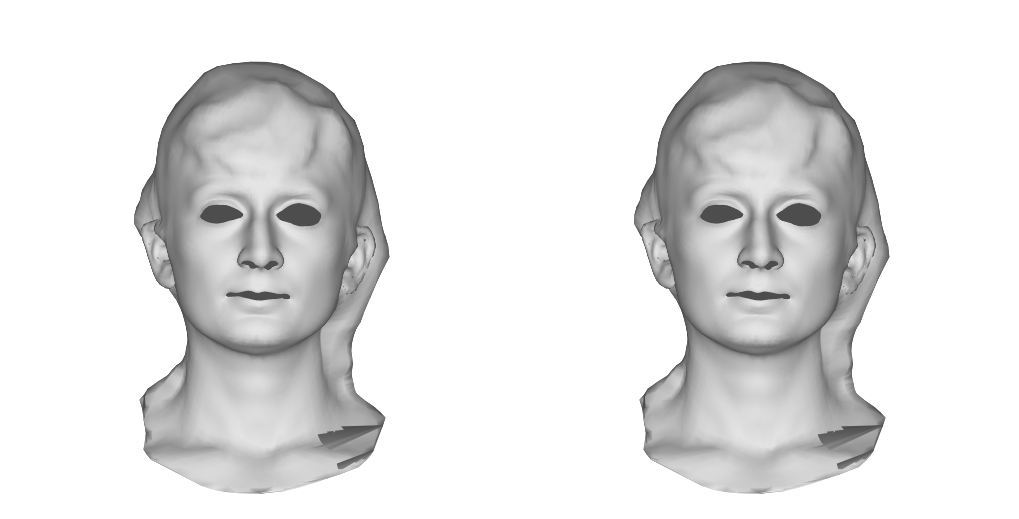

In [8]:
SRC_SELECT_DATA=4
SRC_SELECT_MESH=12
EXP_NUM=1
TGT_SELECT_DATA=4
TGT_SELECT_mesh=12

data_name_list = ['voca','biwi','mf_SEN','coma','mf_ROM','ict','ict-cap']
src_selection = data_name_list[SRC_SELECT_DATA]
tgt_selection = data_name_list[TGT_SELECT_DATA]

if src_selection == 'ict-cap':
    file_name = f'{src_selection}-ID_{SRC_SELECT_MESH:03d}_test-to-{tgt_selection}-ID_{TGT_SELECT_mesh:03d}_test_{EXP_NUM:02d}'
else:
    if 'ict' in  tgt_selection:
        file_name = f'{src_selection}_test-to-ict_test-ID_{TGT_SELECT_mesh:03d}'
    else:
        file_name = f'{src_selection}_test-to-{tgt_selection}_test'


src_dataset = EvalDataset(data_name=src_selection, toggle=False) # if eve-s01
src_v, src_f = get_mesh(src_selection, src_dataset, SRC_SELECT_MESH)
src_n = igl.per_vertex_normals(src_v, src_f)

tgt_dataset = EvalDataset(data_name=tgt_selection, toggle=False) # if eve-s01
tgt_v, tgt_f = get_mesh(tgt_selection, tgt_dataset, TGT_SELECT_mesh)
tgt_n = igl.per_vertex_normals(tgt_v, tgt_f)

M_SCALE = 0.5
print(src_v.shape, tgt_v.shape)
v_list=[ src_v, tgt_v ]
f_list=[ src_f, tgt_f ]
SIZE=5
rot_list=[[0,0,0]]

plot_mesh_gouraud(v_list, f_list, mesh_scale=M_SCALE,
    rot_list=rot_list*len(v_list), size=SIZE, mode='shade', bg_black=False,
    # logdir=f"fig/", name=f"{file_name}-neutral", save=True
)

# design study

In [19]:
src_v.shape

(3525, 3)

In [23]:

        
## version 5
# ckpt = '../ckpts_CBD/2025-09-26-10-16-32-NGBCv5' ## ------> 1 1 test (w/o mask)

# ckpt = '../ckpts_CBD/2025-09-28-14-50-34-NGBCv5' ## ------> 1 1 softplus
# ckpt = '../ckpts_CBD/2025-09-27-08-05-11-NGBCv5' ## ------> 1 1 #### [prev] design study 
# ckpt = '../ckpts_CBD/2025-09-30-16-28-51-NGBCv5' ## ------> 1 1 none
# ckpt = '../ckpts_CBD/2025-09-27-07-44-28-NGBCv5' ## ------> 2 1
# ckpt = '../ckpts_CBD/2025-09-28-15-27-33-NGBCv5' ## ------> 2 0 
# ckpt = '../ckpts_CBD/2025-09-27-12-04-29-NGBCv5' ## ------> 1 0 # delta
# ckpt = '../ckpts_CBD/2025-10-02-00-06-28-NGBCv5' ## ------> 1 2 # matrix
# ckpt = '../ckpts_CBD/2025-10-03-22-40-03-NGBCv5' ## ------> 1 1 relu (soft POU)
# ckpt = '../ckpts_CBD/2025-10-09-01-42-26-NGBCv5' ## ------> 1 1 (128? -> 512)
# ckpt = '../ckpts_CBD/2025-10-09-02-04-49-NGBCv5' ## ------> 1 1 (use_data2) #### [chosen] compare
# ckpt = '../ckpts_CBD/2025-10-09-02-07-57-NGBCv5' ## ------> 1 1 (use_data2)
# ckpt = '../ckpts_CBD/2025-10-11-23-12-33-NGBCv5' ## ------> 1 1 (use_data2)
ckpt = '../ckpts_CBD/2025-10-23-17-32-49-NGBCv5' ## ------> 1 1 #### [chosen] ############################

file_name = 'mf_ROM-masked/verts'
# file_name = 'coma-masked/verts'
eval_path = '/source/sihun/NeuralFacialAnimation/eval_CBD/'
print(eval_path)
# source/sihun/NeuralFacialAnimation/eval_CBD/2025-09-26-10-16-32-NGBCv5-eval/mf_ROM-masked
# '2025-09-26-10-16-32-NGBCv5' '2025-10-22-16-22-45-NGBCv5' '2025-10-22-16-26-26-NGBCv5' '2025-10-03-22-40-03-NGBCv5' '2025-09-28-14-50-34-NGBCv5' '2025-09-30-16-28-51-NGBCv5' '2025-10-08-02-55-02-NGBCv5' '2025-10-23-17-32-49-NGBCv5' '2025-10-24-18-03-51-NGBCv5' '2025-10-24-18-11-21-NGBCv5
mesh_file_paths_no_act = sorted(glob(eval_path+f'2025-09-30-16-28-51-NGBCv5-eval/{file_name}/*.npy'))
# print(mesh_file_paths_no_act)
len_mesh_file_paths_no_act = len(mesh_file_paths_no_act)
print(len_mesh_file_paths_no_act)

mesh_file_paths_w_softplus = sorted(glob(eval_path+f'2025-09-28-14-50-34-NGBCv5-eval/{file_name}/*.npy'))
len_mesh_file_paths_w_softplus = len(mesh_file_paths_w_softplus)
print(len_mesh_file_paths_w_softplus)

# mesh_file_paths_w_relu = sorted(glob(eval_path+f'2025-09-27-08-05-11-NGBCv5-eval/{file_name}/*.npy'))
mesh_file_paths_w_relu = sorted(glob(eval_path+f'2025-10-23-17-32-49-NGBCv5-eval/{file_name}/*.npy'))
len_mesh_file_paths_w_relu = len(mesh_file_paths_w_relu)
print(len_mesh_file_paths_w_relu)

mesh_file_paths_w_elu = sorted(glob(eval_path+f'2025-10-08-02-55-02-NGBCv5-eval/{file_name}/*.npy'))
len_mesh_file_paths_w_elu = len(mesh_file_paths_w_elu)
print(len_mesh_file_paths_w_elu)


# mesh_file_paths_delta = sorted(glob(eval_path+f'2025-09-27-12-04-29-NGBCv5-eval/{file_name}/*.npy'))
mesh_file_paths_delta = sorted(glob(eval_path+f'2025-10-22-16-22-45-NGBCv5-eval/{file_name}/*.npy'))
len_mesh_file_paths_delta = len(mesh_file_paths_delta)
print(len_mesh_file_paths_delta)

# mesh_file_paths_matrix = sorted(glob(eval_path+f'2025-10-02-00-06-28-NGBCv5-eval/{file_name}/*.npy'))
mesh_file_paths_matrix = sorted(glob(eval_path+f'2025-10-22-16-26-26-NGBCv5-eval/{file_name}/*.npy'))
len_mesh_file_paths_matrix = len(mesh_file_paths_matrix)
print(len_mesh_file_paths_matrix)

mesh_file_paths_sPOU = sorted(glob(eval_path+f'2025-10-03-22-40-03-NGBCv5-eval/{file_name}/*.npy'))
len_mesh_file_paths_sPOU = len(mesh_file_paths_sPOU)
print(len_mesh_file_paths_sPOU)

mesh_file_paths_wo_mask = sorted(glob(eval_path+f'2025-09-26-10-16-32-NGBCv5-eval/{file_name}/*.npy'))
len_mesh_file_paths_wo_mask = len(mesh_file_paths_wo_mask)
print(len_mesh_file_paths_wo_mask)

# mesh_file_paths_new = sorted(glob(eval_path+f'2025-10-15-20-15-53-NGBCv5-eval/{file_name}/*.npy'))
# len_mesh_file_paths_new = len(mesh_file_paths_new)
# print(len_mesh_file_paths_new)



if 'ict' in src_selection:
    GT_file_name = f'GT-{src_selection}_test-to-{src_selection}_test_{EXP_NUM:02d}'
else:
    GT_file_name = f'GT-{src_selection}_test-to-{src_selection}_test'

# GT_file_name = "GT_coma_test-to_coma_test"
GT_file_name = "GT-mf_ROM_test-to-mf_ROM_test_00"
GT_a2b_retarget_path = __abs_path__ + '/eval_CBD/'+ GT_file_name
GT_mesh_file_paths = sorted(glob(GT_a2b_retarget_path+'/*.npy'))
GT_len_mesh_file_paths=len(GT_mesh_file_paths)
print(GT_len_mesh_file_paths)



SAVE=0
SIZE=5
rot_list=[[0,0,0]]
# M_SCALE=0.66
# M_TRNS=np.array([0,-0.1,0])
M_SCALE=0.56
M_TRNS=np.array([0,0.05,0])
button=False

rc = {
    "font.family" : "serif", 
    "font.size" : 16,
    "mathtext.fontset" : "stix",
}
FT = 22
plt.rcParams.update(rc)
plt.rcParams["font.serif"] = ["Times New Roman"] + plt.rcParams["font.serif"]

print('|            GT            |            ours            |         w/softplus         |           w/ elu           |           no act           |          delta           |           matrix           |            sPOU            |            w/o mask          |')
def update_frame(frame, y_rot, save):
    global button
    plt.close()
    
    vvvGT= np.load(GT_mesh_file_paths[frame]).squeeze()
    # print(vvvGT.shape)
    
    vvv0= np.load(mesh_file_paths_no_act[frame]).squeeze()
    vvv1= np.load(mesh_file_paths_w_softplus[frame]).squeeze()
    vvv2= np.load(mesh_file_paths_w_relu[frame]).squeeze()
    vvv7= np.load(mesh_file_paths_w_elu[frame]).squeeze()
    vvv3= np.load(mesh_file_paths_delta[frame]).squeeze()
    vvv4= np.load(mesh_file_paths_matrix[frame]).squeeze()
    vvv5= np.load(mesh_file_paths_sPOU[frame]).squeeze()
    vvv6= np.load(mesh_file_paths_wo_mask[frame]).squeeze()
    # vvv7= np.load(mesh_file_paths_new[frame]).squeeze()
    
    v_list = [
        # vvvGT, vvv0, vvv1, vvv2, vvv3, vvv4, vvv5, vvv6
        vvvGT, vvv2, vvv1, vvv7, vvv0, vvv3, vvv4, vvv5, vvv6
    ]
    # print("---".join([f'{vv.shape}' for vv in v_list]))
    
    f_list = [src_f]*len(v_list)
    plot_mesh_gouraud(
        v_list, f_list, mesh_scale=M_SCALE, mesh_trans=M_TRNS,
        is_diff=True, 
        # diff_base=v_list[0], # calculates difference based on this mesh
        diff_base=src_v, # calculates difference based on this mesh
        backface_culling=True,
        rot_list=rot_list*len(v_list), size=SIZE, mode='shade', bg_black=False,
        # logdir='../_tmp',name='',save=False,
    )
    if save!=button:
        name_tmp = file_name.split('/')[0]
        plot_mesh_gouraud(
            v_list, f_list, mesh_scale=M_SCALE, mesh_trans=M_TRNS,
            is_diff=True, 
            diff_base=src_v, # calculates difference based on this mesh
            # diff_base=v_list[0], # calculates difference based on this mesh
            backface_culling=True,
            rot_list=rot_list*len(v_list), size=SIZE, mode='shade', bg_black=False,            
            logdir=f"fig/", name=f"{name_tmp}-{frame:05d}_renew", save=True
        )
        button=save
        print('clicked')
    # v_list = [v * M_SCALE for v in v_list]
    # plot_image_array(
    #         v_list, f_list,
    #         rot_list=rot_list*len(v_list), size=2, mode='shade', bg_black=False
    #     )

# slider = widgets.IntSlider(value=0, min=0, max=len_mesh_file_paths-1, step=1, description='Frame:')

# widgets.interactive(update_frame, frame=slider)
# widgets.interact(update_frame, frame=slider)
sliders = {
    'frame': widgets.IntSlider(value=0, min=0, max=GT_len_mesh_file_paths-1, step=1),
    'y_rot': widgets.FloatSlider(value=0, min=-180, max=180, step=.1),
    'save': widgets.ToggleButton(
        value=False,
        description='save',
        disabled=False,
        button_style='', # 'success', 'info', 'warning', 'danger' or ''
        tooltip='Description',
        icon='check' # (FontAwesome names without the `fa-` prefix)
    )
}
# widgets.interactive(update_frame, frame=slider)
widgets.interact(update_frame, **sliders)

/source/sihun/NeuralFacialAnimation/eval_CBD/
11649
11649
11649
11649
11649
11649
11649
11649
11649
|            GT            |            ours            |         w/softplus         |           w/ elu           |           no act           |          delta           |           matrix           |            sPOU            |            w/o mask          |


interactive(children=(IntSlider(value=0, description='frame', max=11648), FloatSlider(value=0.0, description='…

<function __main__.update_frame(frame, y_rot, save)>

In [8]:
# scp -r -P 30148 root@143.248.249.98:/source/sihun/NeuralFacialAnimation/eval_CBD/GT-mf_ROM_test-to-mf_ROM_test /source/sihun/NeuralFacialAnimation/eval_CBD/GT-mf_ROM_test-to-mf_ROM_test 

[]

In [8]:

from glob import glob
import igl
import numpy as np
import ipywidgets as widgets
import matplotlib.pyplot as plt
from PIL import Image
import pickle



im_paths=sorted(glob('/data/sihun/test/*.png'))
len_im_paths=len(im_paths)
print(len_im_paths)


with open('/data/sihun/pca/multiface_align/mf_templates.pkl', 'rb') as f:
    mesh = pickle.load(f)

def update_frame(frame, y_rot, save):
    global button
    #plt.close()
    
    np.array(Image.open(im_paths[frame]))    
    plt.imshow(np.array(Image.open(im_paths[frame])))
sliders = {
    'frame': widgets.IntSlider(value=0, min=0, max=len_im_paths-1, step=1),
    'y_rot': widgets.FloatSlider(value=0, min=-180, max=180, step=.1),
    'save': widgets.ToggleButton(
        value=False,
        description='save',
        disabled=False,
        button_style='', # 'success', 'info', 'warning', 'danger' or ''
        tooltip='Description',
        icon='check' # (FontAwesome names without the `fa-` prefix)
    )
}
# widgets.interactive(update_frame, frame=slider)
widgets.interact(update_frame, **sliders)

675


interactive(children=(IntSlider(value=0, description='frame', max=674), FloatSlider(value=0.0, description='y_…

<function __main__.update_frame(frame, y_rot, save)>